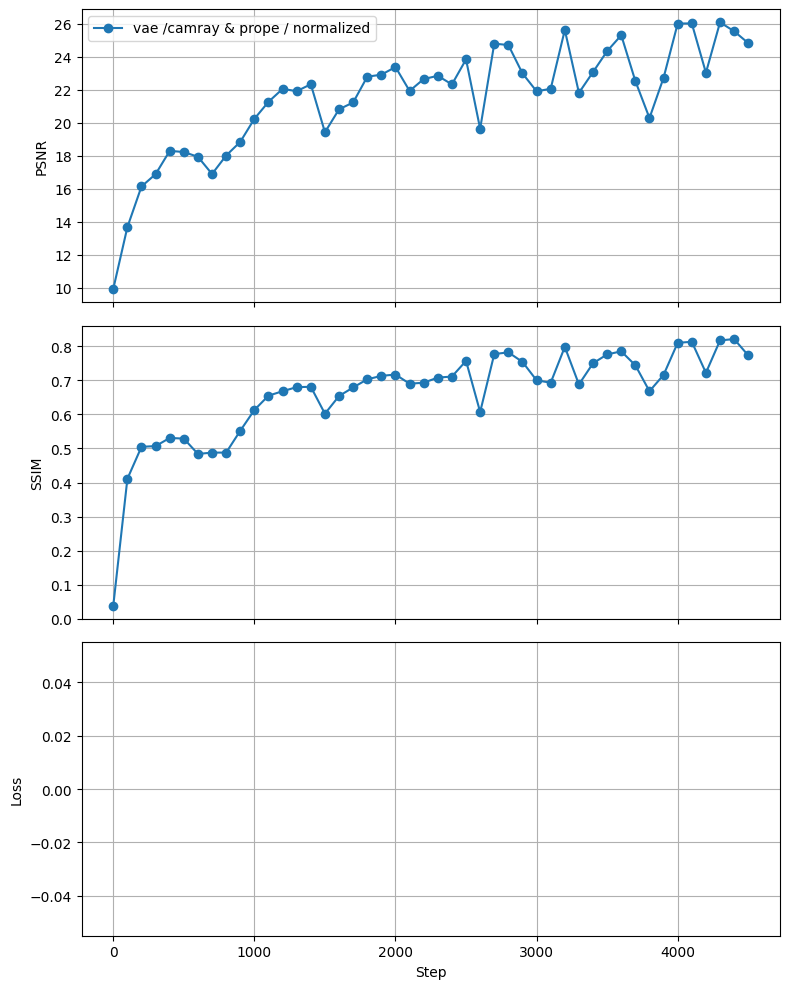

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import re

# Define the raw log texts
log_4 = """[2025-11-07 09:13:18] Step: 0, Loss: nan, PSNR: 11.275, SSIM: 0.040, LPIPS: 0.977, LR: 4.000e-06 [2025-11-07 09:15:54] Step: 100, Loss: nan, PSNR: 13.488, SSIM: 0.406, LPIPS: 0.858, LR: 1.984e-05 [2025-11-07 09:18:20] Step: 200, Loss: nan, PSNR: 15.794, SSIM: 0.501, LPIPS: 0.699, LR: 3.568e-05 [2025-11-07 09:20:46] Step: 300, Loss: nan, PSNR: 16.498, SSIM: 0.508, LPIPS: 0.724, LR: 5.152e-05 [2025-11-07 09:23:10] Step: 400, Loss: nan, PSNR: 18.442, SSIM: 0.521, LPIPS: 0.606, LR: 6.736e-05 [2025-11-07 09:25:34] Step: 500, Loss: nan, PSNR: 17.201, SSIM: 0.495, LPIPS: 0.648, LR: 8.319e-05 [2025-11-07 09:28:00] Step: 600, Loss: nan, PSNR: 19.464, SSIM: 0.557, LPIPS: 0.538, LR: 9.903e-05 [2025-11-07 09:30:27] Step: 700, Loss: nan, PSNR: 19.300, SSIM: 0.541, LPIPS: 0.521, LR: 1.149e-04 [2025-11-07 09:32:54] Step: 800, Loss: nan, PSNR: 19.457, SSIM: 0.555, LPIPS: 0.468, LR: 1.307e-04 [2025-11-07 09:35:21] Step: 900, Loss: nan, PSNR: 19.668, SSIM: 0.578, LPIPS: 0.502, LR: 1.465e-04 [2025-11-07 09:37:48] Step: 1000, Loss: nan, PSNR: 21.422, SSIM: 0.640, LPIPS: 0.428, LR: 1.623e-04 [2025-11-07 09:40:12] Step: 1100, Loss: nan, PSNR: 20.297, SSIM: 0.610, LPIPS: 0.473, LR: 1.782e-04 [2025-11-07 09:42:36] Step: 1200, Loss: nan, PSNR: 21.441, SSIM: 0.654, LPIPS: 0.413, LR: 1.940e-04 [2025-11-07 09:44:57] Step: 1300, Loss: nan, PSNR: 20.716, SSIM: 0.619, LPIPS: 0.443, LR: 2.098e-04 [2025-11-07 09:47:18] Step: 1400, Loss: nan, PSNR: 21.961, SSIM: 0.678, LPIPS: 0.372, LR: 2.256e-04 [2025-11-07 09:49:39] Step: 1500, Loss: nan, PSNR: 21.568, SSIM: 0.670, LPIPS: 0.400, LR: 2.414e-04 [2025-11-07 09:52:00] Step: 1600, Loss: nan, PSNR: 22.463, SSIM: 0.696, LPIPS: 0.366, LR: 2.572e-04 [2025-11-07 09:54:21] Step: 1700, Loss: nan, PSNR: 22.963, SSIM: 0.711, LPIPS: 0.344, LR: 2.730e-04 [2025-11-07 09:56:42] Step: 1800, Loss: nan, PSNR: 22.329, SSIM: 0.704, LPIPS: 0.349, LR: 2.887e-04 [2025-11-07 09:59:03] Step: 1900, Loss: nan, PSNR: 22.029, SSIM: 0.677, LPIPS: 0.383, LR: 3.045e-04 [2025-11-07 10:01:24] Step: 2000, Loss: nan, PSNR: 21.169, SSIM: 0.675, LPIPS: 0.343, LR: 3.203e-04 [2025-11-07 10:03:46] Step: 2100, Loss: nan, PSNR: 23.507, SSIM: 0.733, LPIPS: 0.310, LR: 3.360e-04 [2025-11-07 10:06:07] Step: 2200, Loss: nan, PSNR: 23.241, SSIM: 0.727, LPIPS: 0.326, LR: 3.518e-04 [2025-11-07 10:08:28] Step: 2300, Loss: nan, PSNR: 22.243, SSIM: 0.709, LPIPS: 0.308, LR: 3.675e-04 [2025-11-07 10:10:48] Step: 2400, Loss: nan, PSNR: 23.784, SSIM: 0.751, LPIPS: 0.295, LR: 3.833e-04 [2025-11-07 10:13:08] Step: 2500, Loss: nan, PSNR: 18.630, SSIM: 0.578, LPIPS: 0.394, LR: 3.990e-04 [2025-11-07 10:15:29] Step: 2600, Loss: nan, PSNR: 23.810, SSIM: 0.750, LPIPS: 0.269, LR: 3.989e-04 [2025-11-07 10:17:49] Step: 2700, Loss: nan, PSNR: 24.404, SSIM: 0.764, LPIPS: 0.284, LR: 3.988e-04 [2025-11-07 10:20:09] Step: 2800, Loss: nan, PSNR: 23.028, SSIM: 0.731, LPIPS: 0.306, LR: 3.987e-04 [2025-11-07 10:22:30] Step: 2900, Loss: nan, PSNR: 21.498, SSIM: 0.664, LPIPS: 0.355, LR: 3.986e-04 [2025-11-07 10:24:50] Step: 3000, Loss: nan, PSNR: 21.938, SSIM: 0.673, LPIPS: 0.321, LR: 3.985e-04 [2025-11-07 10:27:11] Step: 3100, Loss: nan, PSNR: 22.205, SSIM: 0.733, LPIPS: 0.276, LR: 3.984e-04 [2025-11-07 10:29:31] Step: 3200, Loss: nan, PSNR: 23.225, SSIM: 0.743, LPIPS: 0.292, LR: 3.983e-04 [2025-11-07 10:31:52] Step: 3300, Loss: nan, PSNR: 25.814, SSIM: 0.814, LPIPS: 0.224, LR: 3.982e-04 [2025-11-07 10:34:12] Step: 3400, Loss: nan, PSNR: 24.751, SSIM: 0.777, LPIPS: 0.257, LR: 3.981e-04 [2025-11-07 10:36:32] Step: 3500, Loss: nan, PSNR: 22.798, SSIM: 0.718, LPIPS: 0.281, LR: 3.980e-04 [2025-11-07 10:38:52] Step: 3600, Loss: nan, PSNR: 24.822, SSIM: 0.776, LPIPS: 0.232, LR: 3.979e-04 [2025-11-07 10:41:13] Step: 3700, Loss: nan, PSNR: 21.474, SSIM: 0.701, LPIPS: 0.265, LR: 3.978e-04 [2025-11-07 10:43:33] Step: 3800, Loss: nan, PSNR: 24.164, SSIM: 0.769, LPIPS: 0.245, LR: 3.976e-04 [2025-11-07 10:45:53] Step: 3900, Loss: nan, PSNR: 22.759, SSIM: 0.730, LPIPS: 0.257, LR: 3.975e-04 [2025-11-07 10:48:14] Step: 4000, Loss: nan, PSNR: 19.721, SSIM: 0.609, LPIPS: 0.347, LR: 3.974e-04 [2025-11-07 10:50:34] Step: 4100, Loss: nan, PSNR: 24.850, SSIM: 0.779, LPIPS: 0.248, LR: 3.972e-04 [2025-11-07 10:52:55] Step: 4200, Loss: nan, PSNR: 25.717, SSIM: 0.812, LPIPS: 0.209, LR: 3.971e-04 [2025-11-07 10:55:15] Step: 4300, Loss: nan, PSNR: 24.345, SSIM: 0.764, LPIPS: 0.260, LR: 3.970e-04 [2025-11-07 10:57:35] Step: 4400, Loss: nan, PSNR: 25.267, SSIM: 0.813, LPIPS: 0.189, LR: 3.968e-04 [2025-11-07 10:59:56] Step: 4500, Loss: nan, PSNR: 25.710, SSIM: 0.812, LPIPS: 0.198, LR: 3.967e-04"""
log_6 = """[2025-11-06 16:56:38] Step: 0, Loss: nan, PSNR: 9.930, SSIM: 0.039, LPIPS: 0.976, LR: 4.000e-06 [2025-11-06 17:00:18] Step: 100, Loss: nan, PSNR: 13.678, SSIM: 0.411, LPIPS: 0.832, LR: 1.984e-05 [2025-11-06 17:03:44] Step: 200, Loss: nan, PSNR: 16.144, SSIM: 0.505, LPIPS: 0.707, LR: 3.568e-05 [2025-11-06 17:07:06] Step: 300, Loss: nan, PSNR: 16.892, SSIM: 0.507, LPIPS: 0.723, LR: 5.152e-05 [2025-11-06 17:10:25] Step: 400, Loss: nan, PSNR: 18.303, SSIM: 0.531, LPIPS: 0.601, LR: 6.736e-05 [2025-11-06 17:13:44] Step: 500, Loss: nan, PSNR: 18.234, SSIM: 0.529, LPIPS: 0.565, LR: 8.319e-05 [2025-11-06 17:16:58] Step: 600, Loss: nan, PSNR: 17.942, SSIM: 0.484, LPIPS: 0.635, LR: 9.903e-05 [2025-11-06 17:20:13] Step: 700, Loss: nan, PSNR: 16.900, SSIM: 0.488, LPIPS: 0.622, LR: 1.149e-04 [2025-11-06 17:23:26] Step: 800, Loss: nan, PSNR: 18.021, SSIM: 0.488, LPIPS: 0.613, LR: 1.307e-04 [2025-11-06 17:26:44] Step: 900, Loss: nan, PSNR: 18.850, SSIM: 0.552, LPIPS: 0.516, LR: 1.465e-04 [2025-11-06 17:29:59] Step: 1000, Loss: nan, PSNR: 20.246, SSIM: 0.613, LPIPS: 0.425, LR: 1.623e-04 [2025-11-06 17:33:16] Step: 1100, Loss: nan, PSNR: 21.278, SSIM: 0.655, LPIPS: 0.406, LR: 1.782e-04 [2025-11-06 17:36:31] Step: 1200, Loss: nan, PSNR: 22.063, SSIM: 0.668, LPIPS: 0.389, LR: 1.940e-04 [2025-11-06 17:39:46] Step: 1300, Loss: nan, PSNR: 21.923, SSIM: 0.680, LPIPS: 0.396, LR: 2.098e-04 [2025-11-06 17:43:00] Step: 1400, Loss: nan, PSNR: 22.343, SSIM: 0.681, LPIPS: 0.369, LR: 2.256e-04 [2025-11-06 17:46:15] Step: 1500, Loss: nan, PSNR: 19.431, SSIM: 0.602, LPIPS: 0.395, LR: 2.414e-04 [2025-11-06 17:49:30] Step: 1600, Loss: nan, PSNR: 20.825, SSIM: 0.654, LPIPS: 0.373, LR: 2.572e-04 [2025-11-06 17:52:46] Step: 1700, Loss: nan, PSNR: 21.238, SSIM: 0.679, LPIPS: 0.367, LR: 2.730e-04 [2025-11-06 17:56:04] Step: 1800, Loss: nan, PSNR: 22.801, SSIM: 0.703, LPIPS: 0.315, LR: 2.887e-04 [2025-11-06 17:59:18] Step: 1900, Loss: nan, PSNR: 22.925, SSIM: 0.713, LPIPS: 0.331, LR: 3.045e-04 [2025-11-06 18:02:29] Step: 2000, Loss: nan, PSNR: 23.387, SSIM: 0.717, LPIPS: 0.323, LR: 3.203e-04 [2025-11-06 18:05:46] Step: 2100, Loss: nan, PSNR: 21.939, SSIM: 0.690, LPIPS: 0.330, LR: 3.360e-04 [2025-11-06 18:09:02] Step: 2200, Loss: nan, PSNR: 22.660, SSIM: 0.693, LPIPS: 0.338, LR: 3.518e-04 [2025-11-06 18:12:19] Step: 2300, Loss: nan, PSNR: 22.855, SSIM: 0.708, LPIPS: 0.334, LR: 3.675e-04 [2025-11-06 18:15:35] Step: 2400, Loss: nan, PSNR: 22.334, SSIM: 0.711, LPIPS: 0.296, LR: 3.833e-04 [2025-11-06 18:18:53] Step: 2500, Loss: nan, PSNR: 23.850, SSIM: 0.757, LPIPS: 0.278, LR: 3.990e-04 [2025-11-06 18:22:09] Step: 2600, Loss: nan, PSNR: 19.641, SSIM: 0.607, LPIPS: 0.425, LR: 3.989e-04 [2025-11-06 18:25:30] Step: 2700, Loss: nan, PSNR: 24.808, SSIM: 0.777, LPIPS: 0.259, LR: 3.988e-04 [2025-11-06 18:28:47] Step: 2800, Loss: nan, PSNR: 24.721, SSIM: 0.782, LPIPS: 0.263, LR: 3.987e-04 [2025-11-06 18:32:03] Step: 2900, Loss: nan, PSNR: 23.001, SSIM: 0.754, LPIPS: 0.263, LR: 3.986e-04 [2025-11-06 18:35:20] Step: 3000, Loss: nan, PSNR: 21.917, SSIM: 0.700, LPIPS: 0.299, LR: 3.985e-04 [2025-11-06 18:38:40] Step: 3100, Loss: nan, PSNR: 22.068, SSIM: 0.693, LPIPS: 0.321, LR: 3.984e-04 [2025-11-06 18:41:53] Step: 3200, Loss: nan, PSNR: 25.640, SSIM: 0.798, LPIPS: 0.236, LR: 3.983e-04 [2025-11-06 18:45:05] Step: 3300, Loss: nan, PSNR: 21.822, SSIM: 0.688, LPIPS: 0.303, LR: 3.982e-04 [2025-11-06 18:48:17] Step: 3400, Loss: nan, PSNR: 23.084, SSIM: 0.750, LPIPS: 0.252, LR: 3.981e-04 [2025-11-06 18:51:29] Step: 3500, Loss: nan, PSNR: 24.354, SSIM: 0.776, LPIPS: 0.237, LR: 3.980e-04 [2025-11-06 18:54:41] Step: 3600, Loss: nan, PSNR: 25.317, SSIM: 0.785, LPIPS: 0.215, LR: 3.979e-04 [2025-11-06 18:57:54] Step: 3700, Loss: nan, PSNR: 22.537, SSIM: 0.744, LPIPS: 0.241, LR: 3.978e-04 [2025-11-06 19:01:06] Step: 3800, Loss: nan, PSNR: 20.294, SSIM: 0.668, LPIPS: 0.268, LR: 3.976e-04 [2025-11-06 19:04:18] Step: 3900, Loss: nan, PSNR: 22.738, SSIM: 0.716, LPIPS: 0.261, LR: 3.975e-04 [2025-11-06 19:07:32] Step: 4000, Loss: nan, PSNR: 26.027, SSIM: 0.810, LPIPS: 0.196, LR: 3.974e-04 [2025-11-06 19:10:49] Step: 4100, Loss: nan, PSNR: 26.033, SSIM: 0.813, LPIPS: 0.218, LR: 3.972e-04 [2025-11-06 19:14:01] Step: 4200, Loss: nan, PSNR: 23.041, SSIM: 0.722, LPIPS: 0.320, LR: 3.971e-04 [2025-11-06 19:17:12] Step: 4300, Loss: nan, PSNR: 26.099, SSIM: 0.817, LPIPS: 0.203, LR: 3.970e-04 [2025-11-06 19:20:24] Step: 4400, Loss: nan, PSNR: 25.558, SSIM: 0.821, LPIPS: 0.207, LR: 3.968e-04 [2025-11-06 19:23:37] Step: 4500, Loss: nan, PSNR: 24.840, SSIM: 0.773, LPIPS: 0.226, LR: 3.967e-04"""

vae_30k = """[2025-11-12 06:43:41] Step: 0, Loss: 0.025, PSNR: 16.028, SSIM: 0.038, LPIPS: 0.000, LR: 4.000e-06
[2025-11-12 06:44:00] Step: 100, Loss: 0.007, PSNR: 21.492, SSIM: 0.226, LPIPS: 0.000, LR: 1.984e-05
[2025-11-12 06:44:05] Step: 200, Loss: 0.006, PSNR: 22.402, SSIM: 0.301, LPIPS: 0.000, LR: 3.568e-05
[2025-11-12 06:44:10] Step: 300, Loss: 0.006, PSNR: 22.575, SSIM: 0.307, LPIPS: 0.000, LR: 5.152e-05
[2025-11-12 06:44:14] Step: 400, Loss: 0.004, PSNR: 23.771, SSIM: 0.413, LPIPS: 0.000, LR: 6.736e-05
[2025-11-12 06:44:19] Step: 500, Loss: 0.004, PSNR: 23.616, SSIM: 0.399, LPIPS: 0.000, LR: 8.319e-05
[2025-11-12 06:44:23] Step: 600, Loss: 0.003, PSNR: 25.087, SSIM: 0.547, LPIPS: 0.000, LR: 9.903e-05
[2025-11-12 06:44:28] Step: 700, Loss: 0.003, PSNR: 25.795, SSIM: 0.586, LPIPS: 0.000, LR: 1.149e-04
[2025-11-12 06:44:33] Step: 800, Loss: 0.003, PSNR: 25.398, SSIM: 0.553, LPIPS: 0.000, LR: 1.307e-04
[2025-11-12 06:44:37] Step: 900, Loss: 0.003, PSNR: 25.045, SSIM: 0.527, LPIPS: 0.000, LR: 1.465e-04
[2025-11-12 06:44:43] Step: 1000, Loss: 0.003, PSNR: 25.758, SSIM: 0.597, LPIPS: 0.000, LR: 1.623e-04
[2025-11-12 06:44:48] Step: 1100, Loss: 0.003, PSNR: 24.589, SSIM: 0.477, LPIPS: 0.000, LR: 1.782e-04
[2025-11-12 06:44:53] Step: 1200, Loss: 0.003, PSNR: 25.470, SSIM: 0.581, LPIPS: 0.000, LR: 1.940e-04
[2025-11-12 06:44:57] Step: 1300, Loss: 0.004, PSNR: 24.212, SSIM: 0.457, LPIPS: 0.000, LR: 2.098e-04
[2025-11-12 06:45:02] Step: 1400, Loss: 0.004, PSNR: 23.855, SSIM: 0.439, LPIPS: 0.000, LR: 2.256e-04
[2025-11-12 06:45:07] Step: 1500, Loss: 0.003, PSNR: 25.675, SSIM: 0.566, LPIPS: 0.000, LR: 2.414e-04
[2025-11-12 06:45:12] Step: 1600, Loss: 0.003, PSNR: 25.020, SSIM: 0.542, LPIPS: 0.000, LR: 2.572e-04
[2025-11-12 06:45:17] Step: 1700, Loss: 0.005, PSNR: 23.441, SSIM: 0.432, LPIPS: 0.000, LR: 2.730e-04
[2025-11-12 06:45:21] Step: 1800, Loss: 0.004, PSNR: 23.972, SSIM: 0.475, LPIPS: 0.000, LR: 2.887e-04
[2025-11-12 06:45:26] Step: 1900, Loss: 0.003, PSNR: 25.829, SSIM: 0.585, LPIPS: 0.000, LR: 3.045e-04
[2025-11-12 06:45:30] Step: 2000, Loss: 0.003, PSNR: 25.015, SSIM: 0.506, LPIPS: 0.000, LR: 3.203e-04
[2025-11-12 06:45:35] Step: 2100, Loss: 0.003, PSNR: 25.841, SSIM: 0.587, LPIPS: 0.000, LR: 3.360e-04
[2025-11-12 06:45:40] Step: 2200, Loss: 0.003, PSNR: 25.227, SSIM: 0.532, LPIPS: 0.000, LR: 3.518e-04
[2025-11-12 06:45:45] Step: 2300, Loss: 0.003, PSNR: 25.301, SSIM: 0.566, LPIPS: 0.000, LR: 3.675e-04
[2025-11-12 06:45:50] Step: 2400, Loss: 0.003, PSNR: 25.771, SSIM: 0.576, LPIPS: 0.000, LR: 3.833e-04
[2025-11-12 06:45:54] Step: 2500, Loss: 0.002, PSNR: 26.522, SSIM: 0.637, LPIPS: 0.000, LR: 3.990e-04
[2025-11-12 06:45:59] Step: 2600, Loss: 0.003, PSNR: 25.953, SSIM: 0.589, LPIPS: 0.000, LR: 3.989e-04
[2025-11-12 06:46:05] Step: 2700, Loss: 0.002, PSNR: 26.075, SSIM: 0.624, LPIPS: 0.000, LR: 3.988e-04
[2025-11-12 06:46:10] Step: 2800, Loss: 0.003, PSNR: 25.558, SSIM: 0.568, LPIPS: 0.000, LR: 3.987e-04
[2025-11-12 06:46:14] Step: 2900, Loss: 0.002, PSNR: 27.651, SSIM: 0.723, LPIPS: 0.000, LR: 3.986e-04
[2025-11-12 06:46:19] Step: 3000, Loss: 0.002, PSNR: 26.566, SSIM: 0.658, LPIPS: 0.000, LR: 3.985e-04
[2025-11-12 06:46:25] Step: 3100, Loss: 0.002, PSNR: 26.103, SSIM: 0.609, LPIPS: 0.000, LR: 3.984e-04
[2025-11-12 06:46:29] Step: 3200, Loss: 0.003, PSNR: 25.651, SSIM: 0.577, LPIPS: 0.000, LR: 3.983e-04
[2025-11-12 06:46:34] Step: 3300, Loss: 0.003, PSNR: 25.739, SSIM: 0.593, LPIPS: 0.000, LR: 3.982e-04
[2025-11-12 06:46:38] Step: 3400, Loss: 0.002, PSNR: 26.470, SSIM: 0.654, LPIPS: 0.000, LR: 3.981e-04
[2025-11-12 06:46:43] Step: 3500, Loss: 0.003, PSNR: 25.323, SSIM: 0.538, LPIPS: 0.000, LR: 3.980e-04
[2025-11-12 06:46:47] Step: 3600, Loss: 0.002, PSNR: 27.020, SSIM: 0.675, LPIPS: 0.000, LR: 3.979e-04
[2025-11-12 06:46:52] Step: 3700, Loss: 0.002, PSNR: 27.629, SSIM: 0.721, LPIPS: 0.000, LR: 3.978e-04
[2025-11-12 06:47:00] Step: 3800, Loss: 0.004, PSNR: 23.902, SSIM: 0.432, LPIPS: 0.000, LR: 3.976e-04
[2025-11-12 06:47:10] Step: 3900, Loss: 0.002, PSNR: 26.271, SSIM: 0.617, LPIPS: 0.000, LR: 3.975e-04
[2025-11-12 06:47:23] Step: 4000, Loss: 0.003, PSNR: 25.855, SSIM: 0.615, LPIPS: 0.000, LR: 3.974e-04
[2025-11-12 06:47:35] Step: 4100, Loss: 0.003, PSNR: 25.782, SSIM: 0.603, LPIPS: 0.000, LR: 3.972e-04
[2025-11-12 06:47:40] Step: 4200, Loss: 0.002, PSNR: 26.291, SSIM: 0.620, LPIPS: 0.000, LR: 3.971e-04
[2025-11-12 06:47:45] Step: 4300, Loss: 0.002, PSNR: 26.390, SSIM: 0.638, LPIPS: 0.000, LR: 3.970e-04
[2025-11-12 06:47:50] Step: 4400, Loss: 0.002, PSNR: 26.436, SSIM: 0.652, LPIPS: 0.000, LR: 3.968e-04
[2025-11-12 06:47:55] Step: 4500, Loss: 0.003, PSNR: 24.772, SSIM: 0.538, LPIPS: 0.000, LR: 3.967e-04
[2025-11-12 06:47:59] Step: 4600, Loss: 0.002, PSNR: 26.166, SSIM: 0.625, LPIPS: 0.000, LR: 3.965e-04
[2025-11-12 06:48:04] Step: 4700, Loss: 0.002, PSNR: 26.476, SSIM: 0.651, LPIPS: 0.000, LR: 3.964e-04
[2025-11-12 06:48:08] Step: 4800, Loss: 0.003, PSNR: 25.633, SSIM: 0.576, LPIPS: 0.000, LR: 3.962e-04
[2025-11-12 06:48:13] Step: 4900, Loss: 0.002, PSNR: 27.597, SSIM: 0.710, LPIPS: 0.000, LR: 3.961e-04
[2025-11-12 06:48:18] Step: 5000, Loss: 0.002, PSNR: 27.936, SSIM: 0.737, LPIPS: 0.000, LR: 3.959e-04
[2025-11-12 06:48:23] Step: 5100, Loss: 0.003, PSNR: 25.945, SSIM: 0.603, LPIPS: 0.000, LR: 3.957e-04
[2025-11-12 06:48:28] Step: 5200, Loss: 0.002, PSNR: 26.968, SSIM: 0.683, LPIPS: 0.000, LR: 3.956e-04
[2025-11-12 06:48:33] Step: 5300, Loss: 0.002, PSNR: 26.244, SSIM: 0.652, LPIPS: 0.000, LR: 3.954e-04
[2025-11-12 06:48:37] Step: 5400, Loss: 0.002, PSNR: 26.884, SSIM: 0.682, LPIPS: 0.000, LR: 3.952e-04
[2025-11-12 06:48:42] Step: 5500, Loss: 0.002, PSNR: 27.648, SSIM: 0.725, LPIPS: 0.000, LR: 3.950e-04
[2025-11-12 06:48:47] Step: 5600, Loss: 0.002, PSNR: 27.023, SSIM: 0.687, LPIPS: 0.000, LR: 3.949e-04
[2025-11-12 06:48:51] Step: 5700, Loss: 0.002, PSNR: 26.537, SSIM: 0.645, LPIPS: 0.000, LR: 3.947e-04
[2025-11-12 06:48:56] Step: 5800, Loss: 0.002, PSNR: 27.188, SSIM: 0.689, LPIPS: 0.000, LR: 3.945e-04
[2025-11-12 06:49:00] Step: 5900, Loss: 0.002, PSNR: 26.755, SSIM: 0.679, LPIPS: 0.000, LR: 3.943e-04
[2025-11-12 06:49:05] Step: 6000, Loss: 0.002, PSNR: 27.092, SSIM: 0.679, LPIPS: 0.000, LR: 3.941e-04
[2025-11-12 06:49:10] Step: 6100, Loss: 0.002, PSNR: 27.096, SSIM: 0.689, LPIPS: 0.000, LR: 3.939e-04
[2025-11-12 06:49:15] Step: 6200, Loss: 0.002, PSNR: 27.175, SSIM: 0.688, LPIPS: 0.000, LR: 3.937e-04
[2025-11-12 06:49:19] Step: 6300, Loss: 0.002, PSNR: 27.156, SSIM: 0.689, LPIPS: 0.000, LR: 3.935e-04
[2025-11-12 06:49:24] Step: 6400, Loss: 0.002, PSNR: 26.427, SSIM: 0.634, LPIPS: 0.000, LR: 3.933e-04
[2025-11-12 06:49:29] Step: 6500, Loss: 0.002, PSNR: 27.431, SSIM: 0.716, LPIPS: 0.000, LR: 3.931e-04
[2025-11-12 06:49:33] Step: 6600, Loss: 0.002, PSNR: 27.430, SSIM: 0.722, LPIPS: 0.000, LR: 3.929e-04
[2025-11-12 06:49:38] Step: 6700, Loss: 0.002, PSNR: 26.972, SSIM: 0.673, LPIPS: 0.000, LR: 3.927e-04
[2025-11-12 06:49:43] Step: 6800, Loss: 0.002, PSNR: 26.567, SSIM: 0.659, LPIPS: 0.000, LR: 3.924e-04
[2025-11-12 06:49:47] Step: 6900, Loss: 0.002, PSNR: 26.618, SSIM: 0.659, LPIPS: 0.000, LR: 3.922e-04
[2025-11-12 06:49:52] Step: 7000, Loss: 0.003, PSNR: 25.842, SSIM: 0.580, LPIPS: 0.000, LR: 3.920e-04
[2025-11-12 06:49:57] Step: 7100, Loss: 0.002, PSNR: 27.652, SSIM: 0.721, LPIPS: 0.000, LR: 3.918e-04
[2025-11-12 06:50:01] Step: 7200, Loss: 0.001, PSNR: 28.618, SSIM: 0.772, LPIPS: 0.000, LR: 3.915e-04
[2025-11-12 06:50:06] Step: 7300, Loss: 0.002, PSNR: 27.310, SSIM: 0.705, LPIPS: 0.000, LR: 3.913e-04
[2025-11-12 06:50:11] Step: 7400, Loss: 0.002, PSNR: 26.466, SSIM: 0.663, LPIPS: 0.000, LR: 3.911e-04
[2025-11-12 06:50:15] Step: 7500, Loss: 0.002, PSNR: 26.983, SSIM: 0.671, LPIPS: 0.000, LR: 3.908e-04
[2025-11-12 06:50:20] Step: 7600, Loss: 0.002, PSNR: 28.022, SSIM: 0.748, LPIPS: 0.000, LR: 3.906e-04
[2025-11-12 06:50:25] Step: 7700, Loss: 0.002, PSNR: 26.143, SSIM: 0.643, LPIPS: 0.000, LR: 3.903e-04
[2025-11-12 06:50:29] Step: 7800, Loss: 0.003, PSNR: 25.917, SSIM: 0.623, LPIPS: 0.000, LR: 3.901e-04
[2025-11-12 06:50:34] Step: 7900, Loss: 0.002, PSNR: 27.616, SSIM: 0.723, LPIPS: 0.000, LR: 3.898e-04
[2025-11-12 06:50:39] Step: 8000, Loss: 0.002, PSNR: 27.836, SSIM: 0.734, LPIPS: 0.000, LR: 3.896e-04
[2025-11-12 06:50:44] Step: 8100, Loss: 0.002, PSNR: 27.365, SSIM: 0.702, LPIPS: 0.000, LR: 3.893e-04
[2025-11-12 06:50:49] Step: 8200, Loss: 0.003, PSNR: 25.861, SSIM: 0.614, LPIPS: 0.000, LR: 3.891e-04
[2025-11-12 06:50:54] Step: 8300, Loss: 0.002, PSNR: 26.130, SSIM: 0.637, LPIPS: 0.000, LR: 3.888e-04
[2025-11-12 06:50:59] Step: 8400, Loss: 0.002, PSNR: 27.028, SSIM: 0.687, LPIPS: 0.000, LR: 3.885e-04
[2025-11-12 06:51:04] Step: 8500, Loss: 0.002, PSNR: 27.243, SSIM: 0.698, LPIPS: 0.000, LR: 3.882e-04
[2025-11-12 06:51:09] Step: 8600, Loss: 0.002, PSNR: 27.097, SSIM: 0.698, LPIPS: 0.000, LR: 3.880e-04
[2025-11-12 06:51:14] Step: 8700, Loss: 0.002, PSNR: 26.030, SSIM: 0.639, LPIPS: 0.000, LR: 3.877e-04
[2025-11-12 06:51:19] Step: 8800, Loss: 0.001, PSNR: 28.331, SSIM: 0.766, LPIPS: 0.000, LR: 3.874e-04
[2025-11-12 06:51:23] Step: 8900, Loss: 0.002, PSNR: 28.197, SSIM: 0.756, LPIPS: 0.000, LR: 3.871e-04
[2025-11-12 06:51:28] Step: 9000, Loss: 0.002, PSNR: 26.290, SSIM: 0.623, LPIPS: 0.000, LR: 3.868e-04
[2025-11-12 06:51:34] Step: 9100, Loss: 0.002, PSNR: 27.196, SSIM: 0.683, LPIPS: 0.000, LR: 3.865e-04
[2025-11-12 06:51:38] Step: 9200, Loss: 0.002, PSNR: 27.622, SSIM: 0.720, LPIPS: 0.000, LR: 3.863e-04
[2025-11-12 06:51:43] Step: 9300, Loss: 0.001, PSNR: 28.902, SSIM: 0.797, LPIPS: 0.000, LR: 3.860e-04
[2025-11-12 06:51:48] Step: 9400, Loss: 0.002, PSNR: 27.220, SSIM: 0.717, LPIPS: 0.000, LR: 3.857e-04
[2025-11-12 06:51:53] Step: 9500, Loss: 0.002, PSNR: 27.912, SSIM: 0.735, LPIPS: 0.000, LR: 3.854e-04
[2025-11-12 06:51:58] Step: 9600, Loss: 0.001, PSNR: 28.306, SSIM: 0.761, LPIPS: 0.000, LR: 3.850e-04
[2025-11-12 06:52:03] Step: 9700, Loss: 0.002, PSNR: 27.684, SSIM: 0.726, LPIPS: 0.000, LR: 3.847e-04
[2025-11-12 06:52:08] Step: 9800, Loss: 0.002, PSNR: 26.378, SSIM: 0.659, LPIPS: 0.000, LR: 3.844e-04
[2025-11-12 06:52:12] Step: 9900, Loss: 0.002, PSNR: 27.993, SSIM: 0.740, LPIPS: 0.000, LR: 3.841e-04
[2025-11-12 06:52:17] Step: 10000, Loss: 0.002, PSNR: 27.534, SSIM: 0.711, LPIPS: 0.000, LR: 3.838e-04
[2025-11-12 06:52:23] Step: 10100, Loss: 0.001, PSNR: 28.366, SSIM: 0.761, LPIPS: 0.000, LR: 3.835e-04
[2025-11-12 06:52:29] Step: 10200, Loss: 0.003, PSNR: 24.704, SSIM: 0.548, LPIPS: 0.000, LR: 3.831e-04
[2025-11-12 06:52:36] Step: 10300, Loss: 0.002, PSNR: 27.223, SSIM: 0.694, LPIPS: 0.000, LR: 3.828e-04
[2025-11-12 06:52:41] Step: 10400, Loss: 0.002, PSNR: 27.667, SSIM: 0.722, LPIPS: 0.000, LR: 3.825e-04
[2025-11-12 06:52:46] Step: 10500, Loss: 0.002, PSNR: 27.156, SSIM: 0.696, LPIPS: 0.000, LR: 3.822e-04
[2025-11-12 06:52:51] Step: 10600, Loss: 0.002, PSNR: 27.272, SSIM: 0.697, LPIPS: 0.000, LR: 3.818e-04
[2025-11-12 06:52:56] Step: 10700, Loss: 0.002, PSNR: 27.426, SSIM: 0.716, LPIPS: 0.000, LR: 3.815e-04
[2025-11-12 06:53:01] Step: 10800, Loss: 0.002, PSNR: 26.730, SSIM: 0.696, LPIPS: 0.000, LR: 3.811e-04
[2025-11-12 06:53:06] Step: 10900, Loss: 0.003, PSNR: 25.186, SSIM: 0.567, LPIPS: 0.000, LR: 3.808e-04
[2025-11-12 06:53:11] Step: 11000, Loss: 0.002, PSNR: 28.040, SSIM: 0.750, LPIPS: 0.000, LR: 3.804e-04
[2025-11-12 06:53:16] Step: 11100, Loss: 0.002, PSNR: 26.976, SSIM: 0.695, LPIPS: 0.000, LR: 3.801e-04
[2025-11-12 06:53:21] Step: 11200, Loss: 0.002, PSNR: 26.859, SSIM: 0.688, LPIPS: 0.000, LR: 3.797e-04
[2025-11-12 06:53:27] Step: 11300, Loss: 0.002, PSNR: 27.450, SSIM: 0.736, LPIPS: 0.000, LR: 3.794e-04
[2025-11-12 06:53:32] Step: 11400, Loss: 0.002, PSNR: 27.342, SSIM: 0.717, LPIPS: 0.000, LR: 3.790e-04
[2025-11-12 06:53:37] Step: 11500, Loss: 0.002, PSNR: 27.769, SSIM: 0.746, LPIPS: 0.000, LR: 3.787e-04
[2025-11-12 06:53:42] Step: 11600, Loss: 0.002, PSNR: 27.970, SSIM: 0.743, LPIPS: 0.000, LR: 3.783e-04
[2025-11-12 06:53:47] Step: 11700, Loss: 0.001, PSNR: 29.142, SSIM: 0.800, LPIPS: 0.000, LR: 3.779e-04
[2025-11-12 06:53:51] Step: 11800, Loss: 0.002, PSNR: 27.394, SSIM: 0.714, LPIPS: 0.000, LR: 3.776e-04
[2025-11-12 06:53:57] Step: 11900, Loss: 0.002, PSNR: 26.944, SSIM: 0.703, LPIPS: 0.000, LR: 3.772e-04
[2025-11-12 06:54:02] Step: 12000, Loss: 0.002, PSNR: 27.110, SSIM: 0.689, LPIPS: 0.000, LR: 3.768e-04
[2025-11-12 06:54:07] Step: 12100, Loss: 0.003, PSNR: 25.650, SSIM: 0.592, LPIPS: 0.000, LR: 3.764e-04
[2025-11-12 06:54:12] Step: 12200, Loss: 0.002, PSNR: 26.951, SSIM: 0.690, LPIPS: 0.000, LR: 3.760e-04
[2025-11-12 06:54:17] Step: 12300, Loss: 0.002, PSNR: 26.919, SSIM: 0.674, LPIPS: 0.000, LR: 3.757e-04
[2025-11-12 06:54:22] Step: 12400, Loss: 0.002, PSNR: 27.060, SSIM: 0.686, LPIPS: 0.000, LR: 3.753e-04
[2025-11-12 06:54:27] Step: 12500, Loss: 0.002, PSNR: 27.455, SSIM: 0.728, LPIPS: 0.000, LR: 3.749e-04
[2025-11-12 06:54:32] Step: 12600, Loss: 0.001, PSNR: 28.537, SSIM: 0.773, LPIPS: 0.000, LR: 3.745e-04
[2025-11-12 06:54:37] Step: 12700, Loss: 0.002, PSNR: 26.886, SSIM: 0.674, LPIPS: 0.000, LR: 3.741e-04
[2025-11-12 06:54:42] Step: 12800, Loss: 0.001, PSNR: 28.518, SSIM: 0.770, LPIPS: 0.000, LR: 3.737e-04
[2025-11-12 06:54:47] Step: 12900, Loss: 0.003, PSNR: 25.786, SSIM: 0.588, LPIPS: 0.000, LR: 3.733e-04
[2025-11-12 06:54:52] Step: 13000, Loss: 0.002, PSNR: 27.873, SSIM: 0.732, LPIPS: 0.000, LR: 3.729e-04
[2025-11-12 06:54:57] Step: 13100, Loss: 0.002, PSNR: 26.638, SSIM: 0.657, LPIPS: 0.000, LR: 3.725e-04
[2025-11-12 06:55:03] Step: 13200, Loss: 0.001, PSNR: 29.087, SSIM: 0.797, LPIPS: 0.000, LR: 3.720e-04
[2025-11-12 06:55:07] Step: 13300, Loss: 0.003, PSNR: 25.255, SSIM: 0.579, LPIPS: 0.000, LR: 3.716e-04
[2025-11-12 06:55:12] Step: 13400, Loss: 0.002, PSNR: 26.791, SSIM: 0.660, LPIPS: 0.000, LR: 3.712e-04
[2025-11-12 06:55:17] Step: 13500, Loss: 0.002, PSNR: 27.481, SSIM: 0.725, LPIPS: 0.000, LR: 3.708e-04
[2025-11-12 06:55:22] Step: 13600, Loss: 0.001, PSNR: 28.341, SSIM: 0.766, LPIPS: 0.000, LR: 3.704e-04
[2025-11-12 06:55:26] Step: 13700, Loss: 0.001, PSNR: 28.273, SSIM: 0.754, LPIPS: 0.000, LR: 3.699e-04
[2025-11-12 06:55:31] Step: 13800, Loss: 0.002, PSNR: 26.806, SSIM: 0.679, LPIPS: 0.000, LR: 3.695e-04
[2025-11-12 06:55:36] Step: 13900, Loss: 0.002, PSNR: 26.827, SSIM: 0.661, LPIPS: 0.000, LR: 3.691e-04
[2025-11-12 06:55:41] Step: 14000, Loss: 0.001, PSNR: 28.533, SSIM: 0.771, LPIPS: 0.000, LR: 3.686e-04
[2025-11-12 06:55:46] Step: 14100, Loss: 0.002, PSNR: 27.693, SSIM: 0.723, LPIPS: 0.000, LR: 3.682e-04
[2025-11-12 06:55:51] Step: 14200, Loss: 0.002, PSNR: 28.124, SSIM: 0.759, LPIPS: 0.000, LR: 3.678e-04
[2025-11-12 06:55:55] Step: 14300, Loss: 0.002, PSNR: 27.888, SSIM: 0.731, LPIPS: 0.000, LR: 3.673e-04
[2025-11-12 06:56:00] Step: 14400, Loss: 0.001, PSNR: 29.285, SSIM: 0.810, LPIPS: 0.000, LR: 3.669e-04
[2025-11-12 06:56:04] Step: 14500, Loss: 0.001, PSNR: 28.362, SSIM: 0.767, LPIPS: 0.000, LR: 3.664e-04
[2025-11-12 06:56:10] Step: 14600, Loss: 0.002, PSNR: 27.129, SSIM: 0.701, LPIPS: 0.000, LR: 3.660e-04
[2025-11-12 06:56:14] Step: 14700, Loss: 0.002, PSNR: 27.752, SSIM: 0.733, LPIPS: 0.000, LR: 3.655e-04
[2025-11-12 06:56:19] Step: 14800, Loss: 0.001, PSNR: 28.419, SSIM: 0.771, LPIPS: 0.000, LR: 3.651e-04
[2025-11-12 06:56:24] Step: 14900, Loss: 0.003, PSNR: 26.008, SSIM: 0.651, LPIPS: 0.000, LR: 3.646e-04
[2025-11-12 06:56:28] Step: 15000, Loss: 0.002, PSNR: 28.003, SSIM: 0.749, LPIPS: 0.000, LR: 3.642e-04
[2025-11-12 06:56:34] Step: 15100, Loss: 0.002, PSNR: 27.527, SSIM: 0.722, LPIPS: 0.000, LR: 3.637e-04
[2025-11-12 06:56:38] Step: 15200, Loss: 0.003, PSNR: 25.509, SSIM: 0.604, LPIPS: 0.000, LR: 3.632e-04
[2025-11-12 06:56:44] Step: 15300, Loss: 0.002, PSNR: 28.150, SSIM: 0.754, LPIPS: 0.000, LR: 3.628e-04
[2025-11-12 06:56:49] Step: 15400, Loss: 0.002, PSNR: 26.313, SSIM: 0.644, LPIPS: 0.000, LR: 3.623e-04
[2025-11-12 06:56:54] Step: 15500, Loss: 0.001, PSNR: 28.851, SSIM: 0.786, LPIPS: 0.000, LR: 3.618e-04
[2025-11-12 06:56:58] Step: 15600, Loss: 0.003, PSNR: 25.477, SSIM: 0.607, LPIPS: 0.000, LR: 3.613e-04
[2025-11-12 06:57:03] Step: 15700, Loss: 0.001, PSNR: 28.948, SSIM: 0.793, LPIPS: 0.000, LR: 3.608e-04
[2025-11-12 06:57:08] Step: 15800, Loss: 0.001, PSNR: 29.368, SSIM: 0.812, LPIPS: 0.000, LR: 3.604e-04
[2025-11-12 06:57:12] Step: 15900, Loss: 0.004, PSNR: 24.377, SSIM: 0.534, LPIPS: 0.000, LR: 3.599e-04
[2025-11-12 06:57:18] Step: 16000, Loss: 0.003, PSNR: 24.601, SSIM: 0.520, LPIPS: 0.000, LR: 3.594e-04
[2025-11-12 06:57:23] Step: 16100, Loss: 0.002, PSNR: 26.994, SSIM: 0.680, LPIPS: 0.000, LR: 3.589e-04
[2025-11-12 06:57:28] Step: 16200, Loss: 0.003, PSNR: 25.866, SSIM: 0.616, LPIPS: 0.000, LR: 3.584e-04
[2025-11-12 06:57:32] Step: 16300, Loss: 0.001, PSNR: 30.028, SSIM: 0.836, LPIPS: 0.000, LR: 3.579e-04
[2025-11-12 06:57:37] Step: 16400, Loss: 0.002, PSNR: 26.297, SSIM: 0.652, LPIPS: 0.000, LR: 3.574e-04
[2025-11-12 06:57:42] Step: 16500, Loss: 0.002, PSNR: 26.289, SSIM: 0.643, LPIPS: 0.000, LR: 3.569e-04
[2025-11-12 06:57:47] Step: 16600, Loss: 0.001, PSNR: 28.284, SSIM: 0.768, LPIPS: 0.000, LR: 3.564e-04
[2025-11-12 06:57:52] Step: 16700, Loss: 0.002, PSNR: 26.274, SSIM: 0.628, LPIPS: 0.000, LR: 3.559e-04
[2025-11-12 06:57:56] Step: 16800, Loss: 0.001, PSNR: 28.792, SSIM: 0.787, LPIPS: 0.000, LR: 3.554e-04
[2025-11-12 06:58:01] Step: 16900, Loss: 0.002, PSNR: 27.325, SSIM: 0.719, LPIPS: 0.000, LR: 3.549e-04
[2025-11-12 06:58:06] Step: 17000, Loss: 0.002, PSNR: 28.185, SSIM: 0.780, LPIPS: 0.000, LR: 3.544e-04
[2025-11-12 06:58:11] Step: 17100, Loss: 0.002, PSNR: 27.626, SSIM: 0.732, LPIPS: 0.000, LR: 3.538e-04
[2025-11-12 06:58:15] Step: 17200, Loss: 0.001, PSNR: 28.789, SSIM: 0.794, LPIPS: 0.000, LR: 3.533e-04
[2025-11-12 06:58:21] Step: 17300, Loss: 0.002, PSNR: 26.209, SSIM: 0.618, LPIPS: 0.000, LR: 3.528e-04
[2025-11-12 06:58:25] Step: 17400, Loss: 0.002, PSNR: 27.866, SSIM: 0.729, LPIPS: 0.000, LR: 3.523e-04
[2025-11-12 06:58:30] Step: 17500, Loss: 0.002, PSNR: 27.652, SSIM: 0.731, LPIPS: 0.000, LR: 3.518e-04
[2025-11-12 06:58:34] Step: 17600, Loss: 0.002, PSNR: 26.518, SSIM: 0.644, LPIPS: 0.000, LR: 3.512e-04
[2025-11-12 06:58:39] Step: 17700, Loss: 0.001, PSNR: 28.399, SSIM: 0.771, LPIPS: 0.000, LR: 3.507e-04
[2025-11-12 06:58:44] Step: 17800, Loss: 0.003, PSNR: 25.492, SSIM: 0.562, LPIPS: 0.000, LR: 3.502e-04
[2025-11-12 06:58:49] Step: 17900, Loss: 0.002, PSNR: 27.439, SSIM: 0.713, LPIPS: 0.000, LR: 3.496e-04
[2025-11-12 06:58:54] Step: 18000, Loss: 0.001, PSNR: 29.484, SSIM: 0.818, LPIPS: 0.000, LR: 3.491e-04
[2025-11-12 06:58:59] Step: 18100, Loss: 0.003, PSNR: 24.903, SSIM: 0.504, LPIPS: 0.000, LR: 3.485e-04
[2025-11-12 06:59:04] Step: 18200, Loss: 0.002, PSNR: 26.248, SSIM: 0.650, LPIPS: 0.000, LR: 3.480e-04
[2025-11-12 06:59:09] Step: 18300, Loss: 0.003, PSNR: 25.893, SSIM: 0.643, LPIPS: 0.000, LR: 3.474e-04
[2025-11-12 06:59:13] Step: 18400, Loss: 0.001, PSNR: 28.793, SSIM: 0.788, LPIPS: 0.000, LR: 3.469e-04
[2025-11-12 06:59:18] Step: 18500, Loss: 0.002, PSNR: 27.276, SSIM: 0.707, LPIPS: 0.000, LR: 3.463e-04
[2025-11-12 06:59:23] Step: 18600, Loss: 0.001, PSNR: 29.489, SSIM: 0.816, LPIPS: 0.000, LR: 3.458e-04
[2025-11-12 06:59:28] Step: 18700, Loss: 0.002, PSNR: 27.418, SSIM: 0.707, LPIPS: 0.000, LR: 3.452e-04
[2025-11-12 06:59:33] Step: 18800, Loss: 0.002, PSNR: 27.620, SSIM: 0.750, LPIPS: 0.000, LR: 3.447e-04
[2025-11-12 06:59:37] Step: 18900, Loss: 0.002, PSNR: 27.510, SSIM: 0.736, LPIPS: 0.000, LR: 3.441e-04
[2025-11-12 06:59:42] Step: 19000, Loss: 0.001, PSNR: 30.474, SSIM: 0.856, LPIPS: 0.000, LR: 3.436e-04
[2025-11-12 06:59:47] Step: 19100, Loss: 0.001, PSNR: 28.634, SSIM: 0.780, LPIPS: 0.000, LR: 3.430e-04
[2025-11-12 06:59:52] Step: 19200, Loss: 0.002, PSNR: 26.444, SSIM: 0.637, LPIPS: 0.000, LR: 3.424e-04
[2025-11-12 06:59:56] Step: 19300, Loss: 0.001, PSNR: 29.852, SSIM: 0.826, LPIPS: 0.000, LR: 3.419e-04
[2025-11-12 07:00:02] Step: 19400, Loss: 0.002, PSNR: 27.240, SSIM: 0.711, LPIPS: 0.000, LR: 3.413e-04
[2025-11-12 07:00:07] Step: 19500, Loss: 0.002, PSNR: 26.869, SSIM: 0.695, LPIPS: 0.000, LR: 3.407e-04
[2025-11-12 07:00:11] Step: 19600, Loss: 0.002, PSNR: 27.302, SSIM: 0.710, LPIPS: 0.000, LR: 3.401e-04
[2025-11-12 07:00:16] Step: 19700, Loss: 0.003, PSNR: 25.558, SSIM: 0.615, LPIPS: 0.000, LR: 3.395e-04
[2025-11-12 07:00:20] Step: 19800, Loss: 0.002, PSNR: 27.984, SSIM: 0.748, LPIPS: 0.000, LR: 3.390e-04
[2025-11-12 07:00:25] Step: 19900, Loss: 0.001, PSNR: 28.737, SSIM: 0.779, LPIPS: 0.000, LR: 3.384e-04
[2025-11-12 07:00:30] Step: 20000, Loss: 0.001, PSNR: 28.583, SSIM: 0.780, LPIPS: 0.000, LR: 3.378e-04
[2025-11-12 07:00:36] Step: 20100, Loss: 0.002, PSNR: 28.173, SSIM: 0.754, LPIPS: 0.000, LR: 3.372e-04
[2025-11-12 07:00:40] Step: 20200, Loss: 0.001, PSNR: 28.829, SSIM: 0.794, LPIPS: 0.000, LR: 3.366e-04
[2025-11-12 07:00:45] Step: 20300, Loss: 0.002, PSNR: 27.488, SSIM: 0.719, LPIPS: 0.000, LR: 3.360e-04
[2025-11-12 07:00:49] Step: 20400, Loss: 0.002, PSNR: 27.628, SSIM: 0.734, LPIPS: 0.000, LR: 3.354e-04
[2025-11-12 07:00:54] Step: 20500, Loss: 0.002, PSNR: 26.530, SSIM: 0.634, LPIPS: 0.000, LR: 3.348e-04
[2025-11-12 07:00:59] Step: 20600, Loss: 0.002, PSNR: 28.207, SSIM: 0.757, LPIPS: 0.000, LR: 3.342e-04
[2025-11-12 07:01:03] Step: 20700, Loss: 0.001, PSNR: 28.618, SSIM: 0.778, LPIPS: 0.000, LR: 3.336e-04
[2025-11-12 07:01:09] Step: 20800, Loss: 0.002, PSNR: 28.140, SSIM: 0.756, LPIPS: 0.000, LR: 3.330e-04
[2025-11-12 07:01:13] Step: 20900, Loss: 0.002, PSNR: 28.200, SSIM: 0.768, LPIPS: 0.000, LR: 3.324e-04
[2025-11-12 07:01:18] Step: 21000, Loss: 0.001, PSNR: 28.511, SSIM: 0.773, LPIPS: 0.000, LR: 3.318e-04
[2025-11-12 07:01:23] Step: 21100, Loss: 0.002, PSNR: 27.858, SSIM: 0.744, LPIPS: 0.000, LR: 3.312e-04
[2025-11-12 07:01:28] Step: 21200, Loss: 0.002, PSNR: 26.198, SSIM: 0.606, LPIPS: 0.000, LR: 3.306e-04
[2025-11-12 07:01:32] Step: 21300, Loss: 0.002, PSNR: 27.017, SSIM: 0.711, LPIPS: 0.000, LR: 3.300e-04
[2025-11-12 07:01:37] Step: 21400, Loss: 0.002, PSNR: 26.619, SSIM: 0.649, LPIPS: 0.000, LR: 3.293e-04
[2025-11-12 07:01:42] Step: 21500, Loss: 0.001, PSNR: 28.737, SSIM: 0.790, LPIPS: 0.000, LR: 3.287e-04
[2025-11-12 07:01:47] Step: 21600, Loss: 0.001, PSNR: 29.340, SSIM: 0.818, LPIPS: 0.000, LR: 3.281e-04
[2025-11-12 07:01:51] Step: 21700, Loss: 0.001, PSNR: 28.967, SSIM: 0.789, LPIPS: 0.000, LR: 3.275e-04
[2025-11-12 07:01:56] Step: 21800, Loss: 0.002, PSNR: 28.166, SSIM: 0.759, LPIPS: 0.000, LR: 3.269e-04
[2025-11-12 07:02:01] Step: 21900, Loss: 0.002, PSNR: 27.514, SSIM: 0.729, LPIPS: 0.000, LR: 3.262e-04
[2025-11-12 07:02:05] Step: 22000, Loss: 0.002, PSNR: 27.748, SSIM: 0.729, LPIPS: 0.000, LR: 3.256e-04
[2025-11-12 07:02:11] Step: 22100, Loss: 0.001, PSNR: 28.984, SSIM: 0.804, LPIPS: 0.000, LR: 3.250e-04
[2025-11-12 07:02:16] Step: 22200, Loss: 0.002, PSNR: 28.007, SSIM: 0.747, LPIPS: 0.000, LR: 3.243e-04
[2025-11-12 07:02:20] Step: 22300, Loss: 0.002, PSNR: 28.090, SSIM: 0.749, LPIPS: 0.000, LR: 3.237e-04
[2025-11-12 07:02:25] Step: 22400, Loss: 0.002, PSNR: 27.798, SSIM: 0.725, LPIPS: 0.000, LR: 3.231e-04
[2025-11-12 07:02:29] Step: 22500, Loss: 0.001, PSNR: 29.977, SSIM: 0.833, LPIPS: 0.000, LR: 3.224e-04
[2025-11-12 07:02:34] Step: 22600, Loss: 0.002, PSNR: 27.748, SSIM: 0.745, LPIPS: 0.000, LR: 3.218e-04
[2025-11-12 07:02:39] Step: 22700, Loss: 0.003, PSNR: 24.848, SSIM: 0.547, LPIPS: 0.000, LR: 3.211e-04
[2025-11-12 07:02:44] Step: 22800, Loss: 0.002, PSNR: 27.351, SSIM: 0.734, LPIPS: 0.000, LR: 3.205e-04
[2025-11-12 07:02:49] Step: 22900, Loss: 0.003, PSNR: 25.323, SSIM: 0.583, LPIPS: 0.000, LR: 3.198e-04
[2025-11-12 07:02:53] Step: 23000, Loss: 0.002, PSNR: 27.307, SSIM: 0.700, LPIPS: 0.000, LR: 3.192e-04
[2025-11-12 07:02:58] Step: 23100, Loss: 0.001, PSNR: 28.714, SSIM: 0.791, LPIPS: 0.000, LR: 3.185e-04
[2025-11-12 07:03:03] Step: 23200, Loss: 0.002, PSNR: 28.226, SSIM: 0.767, LPIPS: 0.000, LR: 3.179e-04
[2025-11-12 07:03:08] Step: 23300, Loss: 0.001, PSNR: 30.099, SSIM: 0.844, LPIPS: 0.000, LR: 3.172e-04
[2025-11-12 07:03:12] Step: 23400, Loss: 0.001, PSNR: 28.709, SSIM: 0.786, LPIPS: 0.000, LR: 3.166e-04
[2025-11-12 07:03:18] Step: 23500, Loss: 0.002, PSNR: 27.697, SSIM: 0.734, LPIPS: 0.000, LR: 3.159e-04
[2025-11-12 07:03:22] Step: 23600, Loss: 0.001, PSNR: 28.451, SSIM: 0.767, LPIPS: 0.000, LR: 3.152e-04
[2025-11-12 07:03:27] Step: 23700, Loss: 0.002, PSNR: 26.936, SSIM: 0.680, LPIPS: 0.000, LR: 3.146e-04
[2025-11-12 07:03:31] Step: 23800, Loss: 0.002, PSNR: 28.236, SSIM: 0.768, LPIPS: 0.000, LR: 3.139e-04
[2025-11-12 07:03:36] Step: 23900, Loss: 0.001, PSNR: 28.604, SSIM: 0.788, LPIPS: 0.000, LR: 3.133e-04
[2025-11-12 07:03:40] Step: 24000, Loss: 0.002, PSNR: 27.304, SSIM: 0.721, LPIPS: 0.000, LR: 3.126e-04
[2025-11-12 07:03:46] Step: 24100, Loss: 0.001, PSNR: 28.846, SSIM: 0.795, LPIPS: 0.000, LR: 3.119e-04
[2025-11-12 07:03:51] Step: 24200, Loss: 0.002, PSNR: 26.154, SSIM: 0.629, LPIPS: 0.000, LR: 3.112e-04
[2025-11-12 07:03:56] Step: 24300, Loss: 0.002, PSNR: 26.042, SSIM: 0.614, LPIPS: 0.000, LR: 3.106e-04
[2025-11-12 07:04:00] Step: 24400, Loss: 0.002, PSNR: 27.609, SSIM: 0.726, LPIPS: 0.000, LR: 3.099e-04
[2025-11-12 07:04:05] Step: 24500, Loss: 0.002, PSNR: 27.708, SSIM: 0.729, LPIPS: 0.000, LR: 3.092e-04
[2025-11-12 07:04:09] Step: 24600, Loss: 0.001, PSNR: 28.722, SSIM: 0.797, LPIPS: 0.000, LR: 3.085e-04
[2025-11-12 07:04:14] Step: 24700, Loss: 0.002, PSNR: 27.916, SSIM: 0.740, LPIPS: 0.000, LR: 3.078e-04
[2025-11-12 07:04:18] Step: 24800, Loss: 0.001, PSNR: 29.395, SSIM: 0.816, LPIPS: 0.000, LR: 3.072e-04
[2025-11-12 07:04:24] Step: 24900, Loss: 0.002, PSNR: 27.807, SSIM: 0.755, LPIPS: 0.000, LR: 3.065e-04
[2025-11-12 07:04:28] Step: 25000, Loss: 0.002, PSNR: 28.174, SSIM: 0.750, LPIPS: 0.000, LR: 3.058e-04
[2025-11-12 07:04:33] Step: 25100, Loss: 0.001, PSNR: 28.250, SSIM: 0.768, LPIPS: 0.000, LR: 3.051e-04
[2025-11-12 07:04:38] Step: 25200, Loss: 0.003, PSNR: 25.537, SSIM: 0.601, LPIPS: 0.000, LR: 3.044e-04
[2025-11-12 07:04:42] Step: 25300, Loss: 0.002, PSNR: 28.191, SSIM: 0.768, LPIPS: 0.000, LR: 3.037e-04
[2025-11-12 07:04:47] Step: 25400, Loss: 0.001, PSNR: 29.990, SSIM: 0.839, LPIPS: 0.000, LR: 3.030e-04
[2025-11-12 07:04:51] Step: 25500, Loss: 0.002, PSNR: 26.874, SSIM: 0.663, LPIPS: 0.000, LR: 3.023e-04
[2025-11-12 07:04:57] Step: 25600, Loss: 0.002, PSNR: 27.196, SSIM: 0.719, LPIPS: 0.000, LR: 3.016e-04
[2025-11-12 07:05:02] Step: 25700, Loss: 0.002, PSNR: 27.712, SSIM: 0.753, LPIPS: 0.000, LR: 3.009e-04
[2025-11-12 07:05:06] Step: 25800, Loss: 0.002, PSNR: 26.169, SSIM: 0.662, LPIPS: 0.000, LR: 3.002e-04
[2025-11-12 07:05:11] Step: 25900, Loss: 0.002, PSNR: 27.941, SSIM: 0.746, LPIPS: 0.000, LR: 2.995e-04
[2025-11-12 07:05:15] Step: 26000, Loss: 0.001, PSNR: 28.743, SSIM: 0.786, LPIPS: 0.000, LR: 2.988e-04
[2025-11-12 07:05:20] Step: 26100, Loss: 0.001, PSNR: 28.801, SSIM: 0.789, LPIPS: 0.000, LR: 2.981e-04
[2025-11-12 07:05:25] Step: 26200, Loss: 0.002, PSNR: 27.294, SSIM: 0.702, LPIPS: 0.000, LR: 2.974e-04
[2025-11-12 07:05:30] Step: 26300, Loss: 0.001, PSNR: 28.418, SSIM: 0.776, LPIPS: 0.000, LR: 2.967e-04
[2025-11-12 07:05:35] Step: 26400, Loss: 0.001, PSNR: 28.686, SSIM: 0.787, LPIPS: 0.000, LR: 2.960e-04
[2025-11-12 07:05:39] Step: 26500, Loss: 0.002, PSNR: 27.608, SSIM: 0.731, LPIPS: 0.000, LR: 2.953e-04
[2025-11-12 07:05:44] Step: 26600, Loss: 0.001, PSNR: 29.150, SSIM: 0.815, LPIPS: 0.000, LR: 2.946e-04
[2025-11-12 07:05:48] Step: 26700, Loss: 0.001, PSNR: 29.139, SSIM: 0.812, LPIPS: 0.000, LR: 2.939e-04
[2025-11-12 07:05:53] Step: 26800, Loss: 0.002, PSNR: 26.121, SSIM: 0.649, LPIPS: 0.000, LR: 2.931e-04
[2025-11-12 07:05:57] Step: 26900, Loss: 0.003, PSNR: 24.860, SSIM: 0.551, LPIPS: 0.000, LR: 2.924e-04
[2025-11-12 07:06:03] Step: 27000, Loss: 0.002, PSNR: 27.872, SSIM: 0.747, LPIPS: 0.000, LR: 2.917e-04
[2025-11-12 07:06:08] Step: 27100, Loss: 0.001, PSNR: 29.143, SSIM: 0.798, LPIPS: 0.000, LR: 2.910e-04
[2025-11-12 07:06:12] Step: 27200, Loss: 0.002, PSNR: 26.714, SSIM: 0.694, LPIPS: 0.000, LR: 2.903e-04
[2025-11-12 07:06:17] Step: 27300, Loss: 0.002, PSNR: 26.535, SSIM: 0.679, LPIPS: 0.000, LR: 2.895e-04
[2025-11-12 07:06:21] Step: 27400, Loss: 0.003, PSNR: 24.717, SSIM: 0.520, LPIPS: 0.000, LR: 2.888e-04
[2025-11-12 07:06:26] Step: 27500, Loss: 0.001, PSNR: 29.101, SSIM: 0.806, LPIPS: 0.000, LR: 2.881e-04
[2025-11-12 07:06:30] Step: 27600, Loss: 0.001, PSNR: 29.298, SSIM: 0.810, LPIPS: 0.000, LR: 2.874e-04
[2025-11-12 07:06:35] Step: 27700, Loss: 0.002, PSNR: 27.945, SSIM: 0.759, LPIPS: 0.000, LR: 2.866e-04
[2025-11-12 07:06:40] Step: 27800, Loss: 0.001, PSNR: 30.390, SSIM: 0.847, LPIPS: 0.000, LR: 2.859e-04
[2025-11-12 07:06:45] Step: 27900, Loss: 0.002, PSNR: 26.421, SSIM: 0.619, LPIPS: 0.000, LR: 2.852e-04
[2025-11-12 07:06:49] Step: 28000, Loss: 0.001, PSNR: 30.014, SSIM: 0.839, LPIPS: 0.000, LR: 2.844e-04
[2025-11-12 07:06:54] Step: 28100, Loss: 0.002, PSNR: 27.607, SSIM: 0.735, LPIPS: 0.000, LR: 2.837e-04
[2025-11-12 07:06:59] Step: 28200, Loss: 0.001, PSNR: 29.836, SSIM: 0.837, LPIPS: 0.000, LR: 2.829e-04
[2025-11-12 07:07:03] Step: 28300, Loss: 0.001, PSNR: 28.613, SSIM: 0.783, LPIPS: 0.000, LR: 2.822e-04
[2025-11-12 07:07:08] Step: 28400, Loss: 0.001, PSNR: 28.320, SSIM: 0.777, LPIPS: 0.000, LR: 2.815e-04
[2025-11-12 07:07:13] Step: 28500, Loss: 0.002, PSNR: 28.222, SSIM: 0.771, LPIPS: 0.000, LR: 2.807e-04
[2025-11-12 07:07:17] Step: 28600, Loss: 0.001, PSNR: 29.694, SSIM: 0.826, LPIPS: 0.000, LR: 2.800e-04
[2025-11-12 07:07:22] Step: 28700, Loss: 0.001, PSNR: 28.955, SSIM: 0.812, LPIPS: 0.000, LR: 2.792e-04
[2025-11-12 07:07:26] Step: 28800, Loss: 0.001, PSNR: 28.739, SSIM: 0.794, LPIPS: 0.000, LR: 2.785e-04
[2025-11-12 07:07:31] Step: 28900, Loss: 0.001, PSNR: 29.229, SSIM: 0.819, LPIPS: 0.000, LR: 2.778e-04
[2025-11-12 07:07:35] Step: 29000, Loss: 0.001, PSNR: 29.287, SSIM: 0.808, LPIPS: 0.000, LR: 2.770e-04
[2025-11-12 07:07:41] Step: 29100, Loss: 0.001, PSNR: 28.951, SSIM: 0.791, LPIPS: 0.000, LR: 2.763e-04
[2025-11-12 07:07:46] Step: 29200, Loss: 0.001, PSNR: 29.236, SSIM: 0.804, LPIPS: 0.000, LR: 2.755e-04
[2025-11-12 07:07:50] Step: 29300, Loss: 0.001, PSNR: 29.951, SSIM: 0.839, LPIPS: 0.000, LR: 2.748e-04
[2025-11-12 07:07:55] Step: 29400, Loss: 0.004, PSNR: 24.335, SSIM: 0.514, LPIPS: 0.000, LR: 2.740e-04
[2025-11-12 07:08:00] Step: 29500, Loss: 0.001, PSNR: 29.905, SSIM: 0.841, LPIPS: 0.000, LR: 2.732e-04
[2025-11-12 07:08:04] Step: 29600, Loss: 0.001, PSNR: 28.858, SSIM: 0.800, LPIPS: 0.000, LR: 2.725e-04
[2025-11-12 07:08:09] Step: 29700, Loss: 0.001, PSNR: 28.307, SSIM: 0.763, LPIPS: 0.000, LR: 2.717e-04
[2025-11-12 07:08:13] Step: 29800, Loss: 0.001, PSNR: 29.524, SSIM: 0.821, LPIPS: 0.000, LR: 2.710e-04
[2025-11-12 07:08:18] Step: 29900, Loss: 0.001, PSNR: 28.930, SSIM: 0.794, LPIPS: 0.000, LR: 2.702e-04
[2025-11-12 07:08:23] Step: 30000, Loss: 0.002, PSNR: 26.162, SSIM: 0.637, LPIPS: 0.000, LR: 2.695e-04"""
no_sigmoid = """[2025-11-13 07:34:28] Step: 0, Loss: 0.590, PSNR: 2.288, SSIM: -0.000, LPIPS: 0.000, LR: 4.000e-06
[2025-11-13 07:34:48] Step: 100, Loss: 0.009, PSNR: 20.379, SSIM: 0.158, LPIPS: 0.000, LR: 1.984e-05
[2025-11-13 07:34:53] Step: 200, Loss: 0.007, PSNR: 21.382, SSIM: 0.231, LPIPS: 0.000, LR: 3.568e-05
[2025-11-13 07:34:57] Step: 300, Loss: 0.006, PSNR: 21.900, SSIM: 0.256, LPIPS: 0.000, LR: 5.152e-05
[2025-11-13 07:35:02] Step: 400, Loss: 0.006, PSNR: 22.500, SSIM: 0.310, LPIPS: 0.000, LR: 6.736e-05
[2025-11-13 07:35:07] Step: 500, Loss: 0.005, PSNR: 23.023, SSIM: 0.342, LPIPS: 0.000, LR: 8.319e-05
[2025-11-13 07:35:11] Step: 600, Loss: 0.005, PSNR: 23.448, SSIM: 0.396, LPIPS: 0.000, LR: 9.903e-05
[2025-11-13 07:35:16] Step: 700, Loss: 0.004, PSNR: 24.342, SSIM: 0.479, LPIPS: 0.000, LR: 1.149e-04
[2025-11-13 07:35:21] Step: 800, Loss: 0.004, PSNR: 24.167, SSIM: 0.453, LPIPS: 0.000, LR: 1.307e-04
[2025-11-13 07:35:26] Step: 900, Loss: 0.004, PSNR: 24.558, SSIM: 0.471, LPIPS: 0.000, LR: 1.465e-04
[2025-11-13 07:35:36] Step: 1000, Loss: 0.003, PSNR: 24.587, SSIM: 0.500, LPIPS: 0.000, LR: 1.623e-04
[2025-11-13 07:35:44] Step: 1100, Loss: 0.004, PSNR: 23.855, SSIM: 0.411, LPIPS: 0.000, LR: 1.782e-04
[2025-11-13 07:35:56] Step: 1200, Loss: 0.003, PSNR: 25.092, SSIM: 0.532, LPIPS: 0.000, LR: 1.940e-04
[2025-11-13 07:36:03] Step: 1300, Loss: 0.004, PSNR: 23.851, SSIM: 0.400, LPIPS: 0.000, LR: 2.098e-04
[2025-11-13 07:36:08] Step: 1400, Loss: 0.004, PSNR: 23.498, SSIM: 0.389, LPIPS: 0.000, LR: 2.256e-04
[2025-11-13 07:36:13] Step: 1500, Loss: 0.003, PSNR: 25.285, SSIM: 0.540, LPIPS: 0.000, LR: 2.414e-04
[2025-11-13 07:36:18] Step: 1600, Loss: 0.003, PSNR: 25.172, SSIM: 0.546, LPIPS: 0.000, LR: 2.572e-04
[2025-11-13 07:36:23] Step: 1700, Loss: 0.003, PSNR: 24.985, SSIM: 0.520, LPIPS: 0.000, LR: 2.730e-04
[2025-11-13 07:36:28] Step: 1800, Loss: 0.003, PSNR: 24.797, SSIM: 0.505, LPIPS: 0.000, LR: 2.887e-04
[2025-11-13 07:36:33] Step: 1900, Loss: 0.003, PSNR: 25.216, SSIM: 0.545, LPIPS: 0.000, LR: 3.045e-04
[2025-11-13 07:36:37] Step: 2000, Loss: 0.004, PSNR: 24.079, SSIM: 0.435, LPIPS: 0.000, LR: 3.203e-04
[2025-11-13 07:36:42] Step: 2100, Loss: 0.003, PSNR: 25.353, SSIM: 0.558, LPIPS: 0.000, LR: 3.360e-04
[2025-11-13 07:36:47] Step: 2200, Loss: 0.003, PSNR: 24.823, SSIM: 0.503, LPIPS: 0.000, LR: 3.518e-04
[2025-11-13 07:36:51] Step: 2300, Loss: 0.003, PSNR: 25.230, SSIM: 0.544, LPIPS: 0.000, LR: 3.675e-04
[2025-11-13 07:36:56] Step: 2400, Loss: 0.003, PSNR: 25.524, SSIM: 0.560, LPIPS: 0.000, LR: 3.833e-04
[2025-11-13 07:37:01] Step: 2500, Loss: 0.003, PSNR: 25.900, SSIM: 0.632, LPIPS: 0.000, LR: 3.990e-04
[2025-11-13 07:37:05] Step: 2600, Loss: 0.003, PSNR: 25.383, SSIM: 0.556, LPIPS: 0.000, LR: 3.989e-04
[2025-11-13 07:37:10] Step: 2700, Loss: 0.003, PSNR: 25.422, SSIM: 0.585, LPIPS: 0.000, LR: 3.988e-04
[2025-11-13 07:37:14] Step: 2800, Loss: 0.003, PSNR: 25.338, SSIM: 0.553, LPIPS: 0.000, LR: 3.987e-04
[2025-11-13 07:37:19] Step: 2900, Loss: 0.002, PSNR: 27.419, SSIM: 0.713, LPIPS: 0.000, LR: 3.986e-04
[2025-11-13 07:37:24] Step: 3000, Loss: 0.003, PSNR: 25.865, SSIM: 0.613, LPIPS: 0.000, LR: 3.985e-04
[2025-11-13 07:37:29] Step: 3100, Loss: 0.003, PSNR: 25.373, SSIM: 0.567, LPIPS: 0.000, LR: 3.984e-04
[2025-11-13 07:37:33] Step: 3200, Loss: 0.004, PSNR: 24.402, SSIM: 0.500, LPIPS: 0.000, LR: 3.983e-04
[2025-11-13 07:37:38] Step: 3300, Loss: 0.003, PSNR: 25.362, SSIM: 0.558, LPIPS: 0.000, LR: 3.982e-04
[2025-11-13 07:37:42] Step: 3400, Loss: 0.002, PSNR: 26.531, SSIM: 0.643, LPIPS: 0.000, LR: 3.981e-04
[2025-11-13 07:37:47] Step: 3500, Loss: 0.003, PSNR: 25.187, SSIM: 0.528, LPIPS: 0.000, LR: 3.980e-04
[2025-11-13 07:37:52] Step: 3600, Loss: 0.002, PSNR: 26.515, SSIM: 0.649, LPIPS: 0.000, LR: 3.979e-04
[2025-11-13 07:37:57] Step: 3700, Loss: 0.002, PSNR: 27.261, SSIM: 0.700, LPIPS: 0.000, LR: 3.978e-04
[2025-11-13 07:38:02] Step: 3800, Loss: 0.003, PSNR: 24.797, SSIM: 0.480, LPIPS: 0.000, LR: 3.976e-04
[2025-11-13 07:38:06] Step: 3900, Loss: 0.002, PSNR: 26.178, SSIM: 0.620, LPIPS: 0.000, LR: 3.975e-04
[2025-11-13 07:38:11] Step: 4000, Loss: 0.003, PSNR: 25.598, SSIM: 0.590, LPIPS: 0.000, LR: 3.974e-04
[2025-11-13 07:38:17] Step: 4100, Loss: 0.003, PSNR: 25.162, SSIM: 0.560, LPIPS: 0.000, LR: 3.972e-04
[2025-11-13 07:38:22] Step: 4200, Loss: 0.002, PSNR: 26.416, SSIM: 0.633, LPIPS: 0.000, LR: 3.971e-04
[2025-11-13 07:38:27] Step: 4300, Loss: 0.002, PSNR: 26.951, SSIM: 0.680, LPIPS: 0.000, LR: 3.970e-04
[2025-11-13 07:38:31] Step: 4400, Loss: 0.002, PSNR: 26.203, SSIM: 0.617, LPIPS: 0.000, LR: 3.968e-04
[2025-11-13 07:38:36] Step: 4500, Loss: 0.003, PSNR: 25.138, SSIM: 0.529, LPIPS: 0.000, LR: 3.967e-04
[2025-11-13 07:38:41] Step: 4600, Loss: 0.002, PSNR: 26.591, SSIM: 0.668, LPIPS: 0.000, LR: 3.965e-04
[2025-11-13 07:38:46] Step: 4700, Loss: 0.002, PSNR: 26.296, SSIM: 0.630, LPIPS: 0.000, LR: 3.964e-04
[2025-11-13 07:38:50] Step: 4800, Loss: 0.003, PSNR: 25.413, SSIM: 0.572, LPIPS: 0.000, LR: 3.962e-04
[2025-11-13 07:38:55] Step: 4900, Loss: 0.002, PSNR: 26.553, SSIM: 0.646, LPIPS: 0.000, LR: 3.961e-04
[2025-11-13 07:39:00] Step: 5000, Loss: 0.002, PSNR: 27.984, SSIM: 0.743, LPIPS: 0.000, LR: 3.959e-04
[2025-11-13 07:39:05] Step: 5100, Loss: 0.002, PSNR: 26.184, SSIM: 0.619, LPIPS: 0.000, LR: 3.957e-04
[2025-11-13 07:39:10] Step: 5200, Loss: 0.002, PSNR: 27.107, SSIM: 0.689, LPIPS: 0.000, LR: 3.956e-04
[2025-11-13 07:39:15] Step: 5300, Loss: 0.002, PSNR: 26.066, SSIM: 0.620, LPIPS: 0.000, LR: 3.954e-04
[2025-11-13 07:39:20] Step: 5400, Loss: 0.002, PSNR: 27.074, SSIM: 0.693, LPIPS: 0.000, LR: 3.952e-04
[2025-11-13 07:39:25] Step: 5500, Loss: 0.002, PSNR: 27.789, SSIM: 0.732, LPIPS: 0.000, LR: 3.950e-04
[2025-11-13 07:39:31] Step: 5600, Loss: 0.003, PSNR: 25.575, SSIM: 0.602, LPIPS: 0.000, LR: 3.949e-04
[2025-11-13 07:39:36] Step: 5700, Loss: 0.002, PSNR: 26.827, SSIM: 0.675, LPIPS: 0.000, LR: 3.947e-04
[2025-11-13 07:39:41] Step: 5800, Loss: 0.002, PSNR: 27.199, SSIM: 0.696, LPIPS: 0.000, LR: 3.945e-04
[2025-11-13 07:39:45] Step: 5900, Loss: 0.003, PSNR: 25.756, SSIM: 0.607, LPIPS: 0.000, LR: 3.943e-04
[2025-11-13 07:39:50] Step: 6000, Loss: 0.002, PSNR: 26.877, SSIM: 0.676, LPIPS: 0.000, LR: 3.941e-04
[2025-11-13 07:39:55] Step: 6100, Loss: 0.002, PSNR: 26.687, SSIM: 0.665, LPIPS: 0.000, LR: 3.939e-04
[2025-11-13 07:39:59] Step: 6200, Loss: 0.002, PSNR: 27.023, SSIM: 0.684, LPIPS: 0.000, LR: 3.937e-04
[2025-11-13 07:40:04] Step: 6300, Loss: 0.002, PSNR: 27.501, SSIM: 0.710, LPIPS: 0.000, LR: 3.935e-04
[2025-11-13 07:40:09] Step: 6400, Loss: 0.002, PSNR: 26.440, SSIM: 0.634, LPIPS: 0.000, LR: 3.933e-04
[2025-11-13 07:40:13] Step: 6500, Loss: 0.002, PSNR: 27.465, SSIM: 0.720, LPIPS: 0.000, LR: 3.931e-04
[2025-11-13 07:40:18] Step: 6600, Loss: 0.002, PSNR: 27.496, SSIM: 0.721, LPIPS: 0.000, LR: 3.929e-04
[2025-11-13 07:40:22] Step: 6700, Loss: 0.002, PSNR: 26.823, SSIM: 0.673, LPIPS: 0.000, LR: 3.927e-04
[2025-11-13 07:40:27] Step: 6800, Loss: 0.002, PSNR: 27.154, SSIM: 0.696, LPIPS: 0.000, LR: 3.924e-04
[2025-11-13 07:40:32] Step: 6900, Loss: 0.002, PSNR: 26.392, SSIM: 0.651, LPIPS: 0.000, LR: 3.922e-04
[2025-11-13 07:40:37] Step: 7000, Loss: 0.003, PSNR: 26.000, SSIM: 0.592, LPIPS: 0.000, LR: 3.920e-04
[2025-11-13 07:40:42] Step: 7100, Loss: 0.002, PSNR: 27.771, SSIM: 0.741, LPIPS: 0.000, LR: 3.918e-04
[2025-11-13 07:40:47] Step: 7200, Loss: 0.001, PSNR: 28.453, SSIM: 0.771, LPIPS: 0.000, LR: 3.915e-04
[2025-11-13 07:40:51] Step: 7300, Loss: 0.002, PSNR: 27.413, SSIM: 0.713, LPIPS: 0.000, LR: 3.913e-04
[2025-11-13 07:40:56] Step: 7400, Loss: 0.002, PSNR: 27.834, SSIM: 0.740, LPIPS: 0.000, LR: 3.911e-04
[2025-11-13 07:41:00] Step: 7500, Loss: 0.002, PSNR: 26.884, SSIM: 0.676, LPIPS: 0.000, LR: 3.908e-04
[2025-11-13 07:41:05] Step: 7600, Loss: 0.002, PSNR: 27.730, SSIM: 0.730, LPIPS: 0.000, LR: 3.906e-04
[2025-11-13 07:41:10] Step: 7700, Loss: 0.003, PSNR: 25.274, SSIM: 0.582, LPIPS: 0.000, LR: 3.903e-04
[2025-11-13 07:41:14] Step: 7800, Loss: 0.002, PSNR: 26.799, SSIM: 0.670, LPIPS: 0.000, LR: 3.901e-04
[2025-11-13 07:41:19] Step: 7900, Loss: 0.002, PSNR: 27.140, SSIM: 0.699, LPIPS: 0.000, LR: 3.898e-04
[2025-11-13 07:41:24] Step: 8000, Loss: 0.002, PSNR: 27.521, SSIM: 0.725, LPIPS: 0.000, LR: 3.896e-04
[2025-11-13 07:41:29] Step: 8100, Loss: 0.002, PSNR: 27.393, SSIM: 0.708, LPIPS: 0.000, LR: 3.893e-04
[2025-11-13 07:41:33] Step: 8200, Loss: 0.002, PSNR: 26.850, SSIM: 0.678, LPIPS: 0.000, LR: 3.891e-04
[2025-11-13 07:41:38] Step: 8300, Loss: 0.002, PSNR: 26.457, SSIM: 0.657, LPIPS: 0.000, LR: 3.888e-04
[2025-11-13 07:41:43] Step: 8400, Loss: 0.002, PSNR: 27.164, SSIM: 0.694, LPIPS: 0.000, LR: 3.885e-04
[2025-11-13 07:41:47] Step: 8500, Loss: 0.002, PSNR: 26.696, SSIM: 0.668, LPIPS: 0.000, LR: 3.882e-04
[2025-11-13 07:41:52] Step: 8600, Loss: 0.002, PSNR: 27.182, SSIM: 0.711, LPIPS: 0.000, LR: 3.880e-04
[2025-11-13 07:41:56] Step: 8700, Loss: 0.002, PSNR: 26.837, SSIM: 0.673, LPIPS: 0.000, LR: 3.877e-04
[2025-11-13 07:42:01] Step: 8800, Loss: 0.001, PSNR: 28.313, SSIM: 0.763, LPIPS: 0.000, LR: 3.874e-04
[2025-11-13 07:42:05] Step: 8900, Loss: 0.002, PSNR: 27.716, SSIM: 0.727, LPIPS: 0.000, LR: 3.871e-04
[2025-11-13 07:42:10] Step: 9000, Loss: 0.002, PSNR: 27.032, SSIM: 0.677, LPIPS: 0.000, LR: 3.868e-04
[2025-11-13 07:42:15] Step: 9100, Loss: 0.002, PSNR: 26.192, SSIM: 0.643, LPIPS: 0.000, LR: 3.865e-04
[2025-11-13 07:42:19] Step: 9200, Loss: 0.002, PSNR: 28.136, SSIM: 0.758, LPIPS: 0.000, LR: 3.863e-04
[2025-11-13 07:42:24] Step: 9300, Loss: 0.001, PSNR: 28.564, SSIM: 0.776, LPIPS: 0.000, LR: 3.860e-04
[2025-11-13 07:42:29] Step: 9400, Loss: 0.001, PSNR: 28.912, SSIM: 0.793, LPIPS: 0.000, LR: 3.857e-04
[2025-11-13 07:42:33] Step: 9500, Loss: 0.002, PSNR: 26.986, SSIM: 0.692, LPIPS: 0.000, LR: 3.854e-04
[2025-11-13 07:42:38] Step: 9600, Loss: 0.001, PSNR: 28.744, SSIM: 0.782, LPIPS: 0.000, LR: 3.850e-04
[2025-11-13 07:42:43] Step: 9700, Loss: 0.002, PSNR: 27.453, SSIM: 0.716, LPIPS: 0.000, LR: 3.847e-04
[2025-11-13 07:42:47] Step: 9800, Loss: 0.002, PSNR: 27.897, SSIM: 0.738, LPIPS: 0.000, LR: 3.844e-04
[2025-11-13 07:42:52] Step: 9900, Loss: 0.002, PSNR: 27.975, SSIM: 0.745, LPIPS: 0.000, LR: 3.841e-04
[2025-11-13 07:42:56] Step: 10000, Loss: 0.003, PSNR: 25.786, SSIM: 0.612, LPIPS: 0.000, LR: 3.838e-04"""
no_f32 = """[2025-11-13 07:56:49] Step: 0, Loss: 0.025, PSNR: 16.028, SSIM: 0.038, LPIPS: 0.000, LR: 4.000e-06
[2025-11-13 07:56:55] Step: 100, Loss: 0.007, PSNR: 21.492, SSIM: 0.225, LPIPS: 0.000, LR: 1.984e-05
[2025-11-13 07:56:59] Step: 200, Loss: 0.006, PSNR: 22.403, SSIM: 0.301, LPIPS: 0.000, LR: 3.568e-05
[2025-11-13 07:57:04] Step: 300, Loss: 0.006, PSNR: 22.572, SSIM: 0.307, LPIPS: 0.000, LR: 5.152e-05
[2025-11-13 07:57:08] Step: 400, Loss: 0.004, PSNR: 23.789, SSIM: 0.414, LPIPS: 0.000, LR: 6.736e-05
[2025-11-13 07:57:13] Step: 500, Loss: 0.004, PSNR: 23.680, SSIM: 0.401, LPIPS: 0.000, LR: 8.319e-05
[2025-11-13 07:57:17] Step: 600, Loss: 0.003, PSNR: 25.094, SSIM: 0.547, LPIPS: 0.000, LR: 9.903e-05
[2025-11-13 07:57:22] Step: 700, Loss: 0.003, PSNR: 25.783, SSIM: 0.589, LPIPS: 0.000, LR: 1.149e-04
[2025-11-13 07:57:26] Step: 800, Loss: 0.003, PSNR: 25.550, SSIM: 0.557, LPIPS: 0.000, LR: 1.307e-04
[2025-11-13 07:57:30] Step: 900, Loss: 0.003, PSNR: 24.902, SSIM: 0.518, LPIPS: 0.000, LR: 1.465e-04
[2025-11-13 07:57:35] Step: 1000, Loss: 0.003, PSNR: 25.699, SSIM: 0.593, LPIPS: 0.000, LR: 1.623e-04
[2025-11-13 07:57:40] Step: 1100, Loss: 0.003, PSNR: 24.632, SSIM: 0.483, LPIPS: 0.000, LR: 1.782e-04
[2025-11-13 07:57:44] Step: 1200, Loss: 0.003, PSNR: 25.438, SSIM: 0.589, LPIPS: 0.000, LR: 1.940e-04
[2025-11-13 07:57:49] Step: 1300, Loss: 0.004, PSNR: 23.948, SSIM: 0.445, LPIPS: 0.000, LR: 2.098e-04
[2025-11-13 07:57:54] Step: 1400, Loss: 0.004, PSNR: 23.641, SSIM: 0.431, LPIPS: 0.000, LR: 2.256e-04
[2025-11-13 07:57:58] Step: 1500, Loss: 0.003, PSNR: 25.423, SSIM: 0.552, LPIPS: 0.000, LR: 2.414e-04
[2025-11-13 07:58:03] Step: 1600, Loss: 0.003, PSNR: 25.736, SSIM: 0.581, LPIPS: 0.000, LR: 2.572e-04
[2025-11-13 07:58:07] Step: 1700, Loss: 0.003, PSNR: 25.724, SSIM: 0.574, LPIPS: 0.000, LR: 2.730e-04
[2025-11-13 07:58:12] Step: 1800, Loss: 0.003, PSNR: 24.970, SSIM: 0.537, LPIPS: 0.000, LR: 2.887e-04
[2025-11-13 07:58:16] Step: 1900, Loss: 0.003, PSNR: 25.690, SSIM: 0.575, LPIPS: 0.000, LR: 3.045e-04
[2025-11-13 07:58:21] Step: 2000, Loss: 0.003, PSNR: 24.821, SSIM: 0.495, LPIPS: 0.000, LR: 3.203e-04
[2025-11-13 07:58:27] Step: 2100, Loss: 0.003, PSNR: 25.715, SSIM: 0.580, LPIPS: 0.000, LR: 3.360e-04
[2025-11-13 07:58:31] Step: 2200, Loss: 0.003, PSNR: 24.913, SSIM: 0.516, LPIPS: 0.000, LR: 3.518e-04
[2025-11-13 07:58:36] Step: 2300, Loss: 0.003, PSNR: 25.562, SSIM: 0.579, LPIPS: 0.000, LR: 3.675e-04
[2025-11-13 07:58:41] Step: 2400, Loss: 0.003, PSNR: 25.832, SSIM: 0.587, LPIPS: 0.000, LR: 3.833e-04
[2025-11-13 07:58:45] Step: 2500, Loss: 0.002, PSNR: 26.547, SSIM: 0.652, LPIPS: 0.000, LR: 3.990e-04
[2025-11-13 07:58:50] Step: 2600, Loss: 0.003, PSNR: 25.807, SSIM: 0.583, LPIPS: 0.000, LR: 3.989e-04
[2025-11-13 07:58:55] Step: 2700, Loss: 0.003, PSNR: 25.266, SSIM: 0.573, LPIPS: 0.000, LR: 3.988e-04
[2025-11-13 07:58:59] Step: 2800, Loss: 0.003, PSNR: 25.097, SSIM: 0.547, LPIPS: 0.000, LR: 3.987e-04
[2025-11-13 07:59:04] Step: 2900, Loss: 0.002, PSNR: 27.710, SSIM: 0.731, LPIPS: 0.000, LR: 3.986e-04
[2025-11-13 07:59:09] Step: 3000, Loss: 0.002, PSNR: 26.592, SSIM: 0.651, LPIPS: 0.000, LR: 3.985e-04
[2025-11-13 07:59:14] Step: 3100, Loss: 0.003, PSNR: 25.632, SSIM: 0.586, LPIPS: 0.000, LR: 3.984e-04
[2025-11-13 07:59:19] Step: 3200, Loss: 0.003, PSNR: 24.975, SSIM: 0.542, LPIPS: 0.000, LR: 3.983e-04
[2025-11-13 07:59:24] Step: 3300, Loss: 0.002, PSNR: 26.258, SSIM: 0.621, LPIPS: 0.000, LR: 3.982e-04
[2025-11-13 07:59:28] Step: 3400, Loss: 0.002, PSNR: 26.558, SSIM: 0.654, LPIPS: 0.000, LR: 3.981e-04
[2025-11-13 07:59:33] Step: 3500, Loss: 0.003, PSNR: 25.446, SSIM: 0.550, LPIPS: 0.000, LR: 3.980e-04
[2025-11-13 07:59:37] Step: 3600, Loss: 0.002, PSNR: 27.021, SSIM: 0.684, LPIPS: 0.000, LR: 3.979e-04
[2025-11-13 07:59:42] Step: 3700, Loss: 0.002, PSNR: 27.660, SSIM: 0.724, LPIPS: 0.000, LR: 3.978e-04
[2025-11-13 07:59:47] Step: 3800, Loss: 0.004, PSNR: 23.766, SSIM: 0.424, LPIPS: 0.000, LR: 3.976e-04
[2025-11-13 07:59:51] Step: 3900, Loss: 0.003, PSNR: 26.010, SSIM: 0.607, LPIPS: 0.000, LR: 3.975e-04
[2025-11-13 07:59:56] Step: 4000, Loss: 0.002, PSNR: 26.235, SSIM: 0.642, LPIPS: 0.000, LR: 3.974e-04
"""
amp_MSE = """[2025-11-13 08:02:08] Step: 0, Loss: 249.580, PSNR: 16.028, SSIM: 0.038, LPIPS: 0.000, LR: 4.000e-06
[2025-11-13 08:02:13] Step: 100, Loss: 71.002, PSNR: 21.487, SSIM: 0.226, LPIPS: 0.000, LR: 1.984e-05
[2025-11-13 08:02:18] Step: 200, Loss: 58.064, PSNR: 22.361, SSIM: 0.301, LPIPS: 0.000, LR: 3.568e-05
[2025-11-13 08:02:22] Step: 300, Loss: 55.788, PSNR: 22.535, SSIM: 0.304, LPIPS: 0.000, LR: 5.152e-05
[2025-11-13 08:02:27] Step: 400, Loss: 41.163, PSNR: 23.855, SSIM: 0.421, LPIPS: 0.000, LR: 6.736e-05
[2025-11-13 08:02:31] Step: 500, Loss: 42.392, PSNR: 23.727, SSIM: 0.405, LPIPS: 0.000, LR: 8.319e-05
[2025-11-13 08:02:36] Step: 600, Loss: 31.128, PSNR: 25.069, SSIM: 0.546, LPIPS: 0.000, LR: 9.903e-05
[2025-11-13 08:02:40] Step: 700, Loss: 26.840, PSNR: 25.712, SSIM: 0.579, LPIPS: 0.000, LR: 1.149e-04
[2025-11-13 08:02:45] Step: 800, Loss: 28.802, PSNR: 25.406, SSIM: 0.552, LPIPS: 0.000, LR: 1.307e-04
[2025-11-13 08:02:49] Step: 900, Loss: 28.340, PSNR: 25.476, SSIM: 0.549, LPIPS: 0.000, LR: 1.465e-04
[2025-11-13 08:02:54] Step: 1000, Loss: 27.971, PSNR: 25.533, SSIM: 0.582, LPIPS: 0.000, LR: 1.623e-04
[2025-11-13 08:02:59] Step: 1100, Loss: 32.795, PSNR: 24.842, SSIM: 0.491, LPIPS: 0.000, LR: 1.782e-04
[2025-11-13 08:03:03] Step: 1200, Loss: 28.370, PSNR: 25.471, SSIM: 0.585, LPIPS: 0.000, LR: 1.940e-04
[2025-11-13 08:03:07] Step: 1300, Loss: 38.233, PSNR: 24.176, SSIM: 0.448, LPIPS: 0.000, LR: 2.098e-04
[2025-11-13 08:03:12] Step: 1400, Loss: 33.950, PSNR: 24.692, SSIM: 0.485, LPIPS: 0.000, LR: 2.256e-04
[2025-11-13 08:03:16] Step: 1500, Loss: 33.794, PSNR: 24.712, SSIM: 0.522, LPIPS: 0.000, LR: 2.414e-04
[2025-11-13 08:03:21] Step: 1600, Loss: 31.208, PSNR: 25.057, SSIM: 0.550, LPIPS: 0.000, LR: 2.572e-04
[2025-11-13 08:03:25] Step: 1700, Loss: 27.488, PSNR: 25.609, SSIM: 0.571, LPIPS: 0.000, LR: 2.730e-04
[2025-11-13 08:03:30] Step: 1800, Loss: 29.405, PSNR: 25.316, SSIM: 0.558, LPIPS: 0.000, LR: 2.887e-04
[2025-11-13 08:03:34] Step: 1900, Loss: 24.675, PSNR: 26.078, SSIM: 0.601, LPIPS: 0.000, LR: 3.045e-04
[2025-11-13 08:03:39] Step: 2000, Loss: 34.850, PSNR: 24.578, SSIM: 0.468, LPIPS: 0.000, LR: 3.203e-04
[2025-11-13 08:03:44] Step: 2100, Loss: 25.695, PSNR: 25.901, SSIM: 0.593, LPIPS: 0.000, LR: 3.360e-04
[2025-11-13 08:03:49] Step: 2200, Loss: 30.411, PSNR: 25.170, SSIM: 0.541, LPIPS: 0.000, LR: 3.518e-04
[2025-11-13 08:03:53] Step: 2300, Loss: 29.170, PSNR: 25.351, SSIM: 0.562, LPIPS: 0.000, LR: 3.675e-04
[2025-11-13 08:03:58] Step: 2400, Loss: 31.415, PSNR: 25.029, SSIM: 0.537, LPIPS: 0.000, LR: 3.833e-04
[2025-11-13 08:04:03] Step: 2500, Loss: 23.442, PSNR: 26.300, SSIM: 0.632, LPIPS: 0.000, LR: 3.990e-04
[2025-11-13 08:04:07] Step: 2600, Loss: 27.346, PSNR: 25.631, SSIM: 0.570, LPIPS: 0.000, LR: 3.989e-04
[2025-11-13 08:04:12] Step: 2700, Loss: 32.395, PSNR: 24.895, SSIM: 0.555, LPIPS: 0.000, LR: 3.988e-04
[2025-11-13 08:04:17] Step: 2800, Loss: 28.813, PSNR: 25.404, SSIM: 0.564, LPIPS: 0.000, LR: 3.987e-04
[2025-11-13 08:04:22] Step: 2900, Loss: 17.778, PSNR: 27.501, SSIM: 0.715, LPIPS: 0.000, LR: 3.986e-04
[2025-11-13 08:04:26] Step: 3000, Loss: 22.113, PSNR: 26.554, SSIM: 0.655, LPIPS: 0.000, LR: 3.985e-04
[2025-11-13 08:04:31] Step: 3100, Loss: 24.011, PSNR: 26.196, SSIM: 0.617, LPIPS: 0.000, LR: 3.984e-04
[2025-11-13 08:04:36] Step: 3200, Loss: 32.130, PSNR: 24.931, SSIM: 0.529, LPIPS: 0.000, LR: 3.983e-04
[2025-11-13 08:04:40] Step: 3300, Loss: 24.981, PSNR: 26.024, SSIM: 0.604, LPIPS: 0.000, LR: 3.982e-04
[2025-11-13 08:04:45] Step: 3400, Loss: 22.057, PSNR: 26.565, SSIM: 0.650, LPIPS: 0.000, LR: 3.981e-04
[2025-11-13 08:04:49] Step: 3500, Loss: 28.669, PSNR: 25.426, SSIM: 0.542, LPIPS: 0.000, LR: 3.980e-04
[2025-11-13 08:04:54] Step: 3600, Loss: 19.743, PSNR: 27.046, SSIM: 0.686, LPIPS: 0.000, LR: 3.979e-04
[2025-11-13 08:04:58] Step: 3700, Loss: 17.374, PSNR: 27.601, SSIM: 0.721, LPIPS: 0.000, LR: 3.978e-04
[2025-11-13 08:05:03] Step: 3800, Loss: 37.132, PSNR: 24.302, SSIM: 0.462, LPIPS: 0.000, LR: 3.976e-04
[2025-11-13 08:05:07] Step: 3900, Loss: 25.946, PSNR: 25.859, SSIM: 0.611, LPIPS: 0.000, LR: 3.975e-04
[2025-11-13 08:05:12] Step: 4000, Loss: 25.988, PSNR: 25.852, SSIM: 0.619, LPIPS: 0.000, LR: 3.974e-04
[2025-11-13 08:05:17] Step: 4100, Loss: 29.898, PSNR: 25.244, SSIM: 0.575, LPIPS: 0.000, LR: 3.972e-04
[2025-11-13 08:05:22] Step: 4200, Loss: 23.829, PSNR: 26.229, SSIM: 0.630, LPIPS: 0.000, LR: 3.971e-04
[2025-11-13 08:05:26] Step: 4300, Loss: 18.104, PSNR: 27.422, SSIM: 0.700, LPIPS: 0.000, LR: 3.970e-04
[2025-11-13 08:05:31] Step: 4400, Loss: 21.276, PSNR: 26.721, SSIM: 0.667, LPIPS: 0.000, LR: 3.968e-04
[2025-11-13 08:05:36] Step: 4500, Loss: 37.268, PSNR: 24.287, SSIM: 0.517, LPIPS: 0.000, LR: 3.967e-04
[2025-11-13 08:05:40] Step: 4600, Loss: 20.820, PSNR: 26.815, SSIM: 0.667, LPIPS: 0.000, LR: 3.965e-04
[2025-11-13 08:05:45] Step: 4700, Loss: 21.676, PSNR: 26.640, SSIM: 0.656, LPIPS: 0.000, LR: 3.964e-04
[2025-11-13 08:05:50] Step: 4800, Loss: 31.074, PSNR: 25.076, SSIM: 0.545, LPIPS: 0.000, LR: 3.962e-04
[2025-11-13 08:05:55] Step: 4900, Loss: 18.496, PSNR: 27.329, SSIM: 0.711, LPIPS: 0.000, LR: 3.961e-04
[2025-11-13 08:06:00] Step: 5000, Loss: 15.105, PSNR: 28.209, SSIM: 0.750, LPIPS: 0.000, LR: 3.959e-04
"""
sum_MSE = """[2025-11-13 08:13:04] Step: 0, Loss: 408.911, PSNR: 16.028, SSIM: 0.038, LPIPS: 0.000, LR: 4.000e-06
[2025-11-13 08:13:10] Step: 100, Loss: 116.445, PSNR: 21.483, SSIM: 0.225, LPIPS: 0.000, LR: 1.984e-05
[2025-11-13 08:13:15] Step: 200, Loss: 95.007, PSNR: 22.367, SSIM: 0.301, LPIPS: 0.000, LR: 3.568e-05
[2025-11-13 08:13:20] Step: 300, Loss: 90.853, PSNR: 22.561, SSIM: 0.305, LPIPS: 0.000, LR: 5.152e-05
[2025-11-13 08:13:24] Step: 400, Loss: 68.804, PSNR: 23.768, SSIM: 0.409, LPIPS: 0.000, LR: 6.736e-05
[2025-11-13 08:13:29] Step: 500, Loss: 68.667, PSNR: 23.777, SSIM: 0.407, LPIPS: 0.000, LR: 8.319e-05
[2025-11-13 08:13:34] Step: 600, Loss: 49.836, PSNR: 25.169, SSIM: 0.553, LPIPS: 0.000, LR: 9.903e-05
[2025-11-13 08:13:38] Step: 700, Loss: 44.044, PSNR: 25.705, SSIM: 0.583, LPIPS: 0.000, LR: 1.149e-04
[2025-11-13 08:13:43] Step: 800, Loss: 44.156, PSNR: 25.694, SSIM: 0.566, LPIPS: 0.000, LR: 1.307e-04
[2025-11-13 08:13:48] Step: 900, Loss: 53.856, PSNR: 24.832, SSIM: 0.514, LPIPS: 0.000, LR: 1.465e-04
[2025-11-13 08:13:52] Step: 1000, Loss: 46.604, PSNR: 25.460, SSIM: 0.577, LPIPS: 0.000, LR: 1.623e-04
[2025-11-13 08:13:58] Step: 1100, Loss: 54.838, PSNR: 24.753, SSIM: 0.487, LPIPS: 0.000, LR: 1.782e-04
[2025-11-13 08:14:02] Step: 1200, Loss: 40.788, PSNR: 26.039, SSIM: 0.608, LPIPS: 0.000, LR: 1.940e-04
[2025-11-13 08:14:07] Step: 1300, Loss: 58.103, PSNR: 24.502, SSIM: 0.459, LPIPS: 0.000, LR: 2.098e-04
[2025-11-13 08:14:11] Step: 1400, Loss: 54.440, PSNR: 24.785, SSIM: 0.484, LPIPS: 0.000, LR: 2.256e-04
[2025-11-13 08:14:16] Step: 1500, Loss: 46.741, PSNR: 25.447, SSIM: 0.561, LPIPS: 0.000, LR: 2.414e-04
[2025-11-13 08:14:20] Step: 1600, Loss: 49.531, PSNR: 25.195, SSIM: 0.551, LPIPS: 0.000, LR: 2.572e-04
[2025-11-13 08:14:25] Step: 1700, Loss: 48.378, PSNR: 25.298, SSIM: 0.546, LPIPS: 0.000, LR: 2.730e-04
[2025-11-13 08:14:29] Step: 1800, Loss: 56.315, PSNR: 24.638, SSIM: 0.520, LPIPS: 0.000, LR: 2.887e-04
[2025-11-13 08:14:34] Step: 1900, Loss: 42.117, PSNR: 25.900, SSIM: 0.590, LPIPS: 0.000, LR: 3.045e-04
[2025-11-13 08:14:38] Step: 2000, Loss: 52.728, PSNR: 24.924, SSIM: 0.494, LPIPS: 0.000, LR: 3.203e-04
[2025-11-13 08:14:43] Step: 2100, Loss: 46.509, PSNR: 25.469, SSIM: 0.560, LPIPS: 0.000, LR: 3.360e-04
[2025-11-13 08:14:48] Step: 2200, Loss: 48.866, PSNR: 25.254, SSIM: 0.536, LPIPS: 0.000, LR: 3.518e-04
[2025-11-13 08:14:52] Step: 2300, Loss: 60.862, PSNR: 24.301, SSIM: 0.505, LPIPS: 0.000, LR: 3.675e-04
[2025-11-13 08:14:56] Step: 2400, Loss: 41.910, PSNR: 25.921, SSIM: 0.592, LPIPS: 0.000, LR: 3.833e-04
[2025-11-13 08:15:01] Step: 2500, Loss: 35.179, PSNR: 26.681, SSIM: 0.647, LPIPS: 0.000, LR: 3.990e-04
[2025-11-13 08:15:05] Step: 2600, Loss: 57.126, PSNR: 24.576, SSIM: 0.506, LPIPS: 0.000, LR: 3.989e-04
[2025-11-13 08:15:10] Step: 2700, Loss: 34.847, PSNR: 26.723, SSIM: 0.664, LPIPS: 0.000, LR: 3.988e-04
[2025-11-13 08:15:15] Step: 2800, Loss: 43.784, PSNR: 25.731, SSIM: 0.583, LPIPS: 0.000, LR: 3.987e-04
[2025-11-13 08:15:19] Step: 2900, Loss: 26.303, PSNR: 27.944, SSIM: 0.738, LPIPS: 0.000, LR: 3.986e-04
[2025-11-13 08:15:24] Step: 3000, Loss: 37.156, PSNR: 26.444, SSIM: 0.650, LPIPS: 0.000, LR: 3.985e-04
[2025-11-13 08:15:29] Step: 3100, Loss: 39.598, PSNR: 26.167, SSIM: 0.625, LPIPS: 0.000, LR: 3.984e-04
[2025-11-13 08:15:33] Step: 3200, Loss: 64.162, PSNR: 24.071, SSIM: 0.485, LPIPS: 0.000, LR: 3.983e-04
[2025-11-13 08:15:38] Step: 3300, Loss: 43.572, PSNR: 25.752, SSIM: 0.589, LPIPS: 0.000, LR: 3.982e-04
[2025-11-13 08:15:43] Step: 3400, Loss: 39.735, PSNR: 26.152, SSIM: 0.625, LPIPS: 0.000, LR: 3.981e-04
[2025-11-13 08:15:47] Step: 3500, Loss: 45.923, PSNR: 25.524, SSIM: 0.555, LPIPS: 0.000, LR: 3.980e-04
[2025-11-13 08:15:51] Step: 3600, Loss: 33.475, PSNR: 26.897, SSIM: 0.671, LPIPS: 0.000, LR: 3.979e-04
[2025-11-13 08:15:56] Step: 3700, Loss: 28.732, PSNR: 27.560, SSIM: 0.719, LPIPS: 0.000, LR: 3.978e-04
[2025-11-13 08:16:01] Step: 3800, Loss: 66.489, PSNR: 23.917, SSIM: 0.429, LPIPS: 0.000, LR: 3.976e-04
[2025-11-13 08:16:05] Step: 3900, Loss: 38.386, PSNR: 26.302, SSIM: 0.623, LPIPS: 0.000, LR: 3.975e-04
[2025-11-13 08:16:10] Step: 4000, Loss: 43.217, PSNR: 25.788, SSIM: 0.616, LPIPS: 0.000, LR: 3.974e-04
[2025-11-13 08:16:15] Step: 4100, Loss: 40.624, PSNR: 26.056, SSIM: 0.610, LPIPS: 0.000, LR: 3.972e-04
[2025-11-13 08:16:19] Step: 4200, Loss: 37.723, PSNR: 26.378, SSIM: 0.628, LPIPS: 0.000, LR: 3.971e-04
[2025-11-13 08:16:24] Step: 4300, Loss: 28.997, PSNR: 27.521, SSIM: 0.712, LPIPS: 0.000, LR: 3.970e-04
[2025-11-13 08:16:29] Step: 4400, Loss: 31.105, PSNR: 27.216, SSIM: 0.685, LPIPS: 0.000, LR: 3.968e-04
[2025-11-13 08:16:33] Step: 4500, Loss: 39.146, PSNR: 26.217, SSIM: 0.615, LPIPS: 0.000, LR: 3.967e-04
[2025-11-13 08:16:38] Step: 4600, Loss: 39.127, PSNR: 26.219, SSIM: 0.638, LPIPS: 0.000, LR: 3.965e-04
[2025-11-13 08:16:42] Step: 4700, Loss: 33.863, PSNR: 26.847, SSIM: 0.666, LPIPS: 0.000, LR: 3.964e-04
[2025-11-13 08:16:47] Step: 4800, Loss: 57.725, PSNR: 24.531, SSIM: 0.517, LPIPS: 0.000, LR: 3.962e-04
[2025-11-13 08:16:51] Step: 4900, Loss: 29.394, PSNR: 27.462, SSIM: 0.709, LPIPS: 0.000, LR: 3.961e-04
[2025-11-13 08:16:56] Step: 5000, Loss: 27.018, PSNR: 27.828, SSIM: 0.730, LPIPS: 0.000, LR: 3.959e-04"""

plucker_px = """[2025-11-11 10:28:56] Step: 0, Loss: 0.492, PSNR: 9.970, SSIM: 0.041, LPIPS: 1.071, LR: 4.000e-06
[2025-11-11 10:32:11] Step: 100, Loss: 0.366, PSNR: 12.208, SSIM: 0.279, LPIPS: 0.978, LR: 1.984e-05
[2025-11-11 10:35:18] Step: 200, Loss: 0.323, PSNR: 13.731, SSIM: 0.393, LPIPS: 0.835, LR: 3.568e-05
[2025-11-11 10:38:27] Step: 300, Loss: 0.306, PSNR: 14.729, SSIM: 0.406, LPIPS: 0.728, LR: 5.152e-05
[2025-11-11 10:41:33] Step: 400, Loss: 0.291, PSNR: 15.114, SSIM: 0.450, LPIPS: 0.743, LR: 6.736e-05
[2025-11-11 10:44:37] Step: 500, Loss: 0.314, PSNR: 14.147, SSIM: 0.447, LPIPS: 0.750, LR: 8.319e-05
[2025-11-11 10:47:42] Step: 600, Loss: 0.315, PSNR: 14.268, SSIM: 0.440, LPIPS: 0.762, LR: 9.903e-05
[2025-11-11 10:50:47] Step: 700, Loss: 0.301, PSNR: 14.473, SSIM: 0.468, LPIPS: 0.730, LR: 1.149e-04
[2025-11-11 10:53:52] Step: 800, Loss: 0.348, PSNR: 13.353, SSIM: 0.396, LPIPS: 0.797, LR: 1.307e-04
[2025-11-11 10:56:57] Step: 900, Loss: 0.291, PSNR: 14.584, SSIM: 0.462, LPIPS: 0.606, LR: 1.465e-04
[2025-11-11 11:00:03] Step: 1000, Loss: 0.259, PSNR: 16.195, SSIM: 0.483, LPIPS: 0.608, LR: 1.623e-04
[2025-11-11 11:03:08] Step: 1100, Loss: 0.261, PSNR: 15.876, SSIM: 0.479, LPIPS: 0.562, LR: 1.782e-04
[2025-11-11 11:06:13] Step: 1200, Loss: 0.267, PSNR: 16.080, SSIM: 0.475, LPIPS: 0.626, LR: 1.940e-04
[2025-11-11 11:09:18] Step: 1300, Loss: 0.243, PSNR: 16.717, SSIM: 0.515, LPIPS: 0.574, LR: 2.098e-04
[2025-11-11 11:12:22] Step: 1400, Loss: 0.230, PSNR: 17.447, SSIM: 0.512, LPIPS: 0.510, LR: 2.256e-04
[2025-11-11 11:15:28] Step: 1500, Loss: 0.277, PSNR: 15.449, SSIM: 0.480, LPIPS: 0.636, LR: 2.414e-04
[2025-11-11 11:18:32] Step: 1600, Loss: 0.236, PSNR: 16.901, SSIM: 0.502, LPIPS: 0.519, LR: 2.572e-04
[2025-11-11 11:21:38] Step: 1700, Loss: 0.276, PSNR: 15.331, SSIM: 0.488, LPIPS: 0.617, LR: 2.730e-04
[2025-11-11 11:24:42] Step: 1800, Loss: 0.214, PSNR: 18.044, SSIM: 0.527, LPIPS: 0.488, LR: 2.887e-04
[2025-11-11 11:27:48] Step: 1900, Loss: 0.224, PSNR: 17.609, SSIM: 0.514, LPIPS: 0.486, LR: 3.045e-04
[2025-11-11 11:30:52] Step: 2000, Loss: 0.223, PSNR: 17.303, SSIM: 0.514, LPIPS: 0.475, LR: 3.203e-04
[2025-11-11 11:33:58] Step: 2100, Loss: 0.238, PSNR: 16.681, SSIM: 0.500, LPIPS: 0.498, LR: 3.360e-04
[2025-11-11 11:37:03] Step: 2200, Loss: 0.239, PSNR: 16.887, SSIM: 0.501, LPIPS: 0.552, LR: 3.518e-04
[2025-11-11 11:40:08] Step: 2300, Loss: 0.229, PSNR: 17.022, SSIM: 0.516, LPIPS: 0.529, LR: 3.675e-04
[2025-11-11 11:43:11] Step: 2400, Loss: 0.239, PSNR: 16.850, SSIM: 0.494, LPIPS: 0.495, LR: 3.833e-04
[2025-11-11 11:46:16] Step: 2500, Loss: 0.234, PSNR: 16.764, SSIM: 0.523, LPIPS: 0.444, LR: 3.990e-04
[2025-11-11 11:49:20] Step: 2600, Loss: 0.247, PSNR: 16.282, SSIM: 0.494, LPIPS: 0.544, LR: 3.989e-04
[2025-11-11 11:52:25] Step: 2700, Loss: 0.198, PSNR: 18.383, SSIM: 0.549, LPIPS: 0.406, LR: 3.988e-04
[2025-11-11 11:55:29] Step: 2800, Loss: 0.275, PSNR: 15.090, SSIM: 0.473, LPIPS: 0.568, LR: 3.987e-04
[2025-11-11 11:58:33] Step: 2900, Loss: 0.272, PSNR: 15.278, SSIM: 0.482, LPIPS: 0.498, LR: 3.986e-04
[2025-11-11 12:01:37] Step: 3000, Loss: 0.334, PSNR: 13.710, SSIM: 0.429, LPIPS: 0.701, LR: 3.985e-04
[2025-11-11 12:04:42] Step: 3100, Loss: 0.267, PSNR: 15.303, SSIM: 0.466, LPIPS: 0.511, LR: 3.984e-04
[2025-11-11 12:07:46] Step: 3200, Loss: 0.191, PSNR: 18.601, SSIM: 0.565, LPIPS: 0.363, LR: 3.983e-04
[2025-11-11 12:10:51] Step: 3300, Loss: 0.298, PSNR: 14.484, SSIM: 0.445, LPIPS: 0.536, LR: 3.982e-04
[2025-11-11 12:13:54] Step: 3400, Loss: 0.212, PSNR: 17.720, SSIM: 0.534, LPIPS: 0.416, LR: 3.981e-04
[2025-11-11 12:17:01] Step: 3500, Loss: 0.212, PSNR: 17.460, SSIM: 0.529, LPIPS: 0.366, LR: 3.980e-04
[2025-11-11 12:20:05] Step: 3600, Loss: 0.194, PSNR: 18.201, SSIM: 0.563, LPIPS: 0.349, LR: 3.979e-04
[2025-11-11 12:23:12] Step: 3700, Loss: 0.196, PSNR: 18.625, SSIM: 0.561, LPIPS: 0.398, LR: 3.978e-04
[2025-11-11 12:26:18] Step: 3800, Loss: 0.256, PSNR: 15.897, SSIM: 0.501, LPIPS: 0.495, LR: 3.976e-04
[2025-11-11 12:29:25] Step: 3900, Loss: 0.237, PSNR: 16.701, SSIM: 0.508, LPIPS: 0.476, LR: 3.975e-04
[2025-11-11 12:32:30] Step: 4000, Loss: 0.216, PSNR: 16.868, SSIM: 0.538, LPIPS: 0.373, LR: 3.974e-04
[2025-11-11 12:35:37] Step: 4100, Loss: 0.211, PSNR: 17.494, SSIM: 0.527, LPIPS: 0.367, LR: 3.972e-04
[2025-11-11 12:38:41] Step: 4200, Loss: 0.267, PSNR: 15.536, SSIM: 0.465, LPIPS: 0.485, LR: 3.971e-04
[2025-11-11 12:41:48] Step: 4300, Loss: 0.219, PSNR: 16.743, SSIM: 0.533, LPIPS: 0.353, LR: 3.970e-04
[2025-11-11 12:44:52] Step: 4400, Loss: 0.184, PSNR: 18.782, SSIM: 0.576, LPIPS: 0.333, LR: 3.968e-04
[2025-11-11 12:47:58] Step: 4500, Loss: 0.249, PSNR: 16.216, SSIM: 0.488, LPIPS: 0.478, LR: 3.967e-04
[2025-11-11 12:51:03] Step: 4600, Loss: 0.214, PSNR: 16.684, SSIM: 0.533, LPIPS: 0.350, LR: 3.965e-04
[2025-11-11 12:54:09] Step: 4700, Loss: 0.229, PSNR: 16.789, SSIM: 0.507, LPIPS: 0.425, LR: 3.964e-04
[2025-11-11 12:57:15] Step: 4800, Loss: 0.226, PSNR: 17.010, SSIM: 0.512, LPIPS: 0.400, LR: 3.962e-04
[2025-11-11 13:00:20] Step: 4900, Loss: 0.178, PSNR: 18.948, SSIM: 0.578, LPIPS: 0.332, LR: 3.961e-04
[2025-11-11 13:03:26] Step: 5000, Loss: 0.177, PSNR: 18.764, SSIM: 0.574, LPIPS: 0.298, LR: 3.959e-04
[2025-11-11 13:06:31] Step: 5100, Loss: 0.154, PSNR: 20.106, SSIM: 0.616, LPIPS: 0.262, LR: 3.957e-04
[2025-11-11 13:09:37] Step: 5200, Loss: 0.163, PSNR: 19.549, SSIM: 0.605, LPIPS: 0.268, LR: 3.956e-04
[2025-11-11 13:12:42] Step: 5300, Loss: 0.148, PSNR: 20.245, SSIM: 0.627, LPIPS: 0.238, LR: 3.954e-04
[2025-11-11 13:15:48] Step: 5400, Loss: 0.178, PSNR: 18.537, SSIM: 0.577, LPIPS: 0.280, LR: 3.952e-04
[2025-11-11 13:18:53] Step: 5500, Loss: 0.185, PSNR: 18.532, SSIM: 0.562, LPIPS: 0.281, LR: 3.950e-04
[2025-11-11 13:21:59] Step: 5600, Loss: 0.160, PSNR: 19.687, SSIM: 0.609, LPIPS: 0.284, LR: 3.949e-04
[2025-11-11 13:25:04] Step: 5700, Loss: 0.159, PSNR: 19.857, SSIM: 0.609, LPIPS: 0.264, LR: 3.947e-04
[2025-11-11 13:28:10] Step: 5800, Loss: 0.193, PSNR: 18.065, SSIM: 0.559, LPIPS: 0.301, LR: 3.945e-04
[2025-11-11 13:31:15] Step: 5900, Loss: 0.140, PSNR: 20.464, SSIM: 0.644, LPIPS: 0.224, LR: 3.943e-04
[2025-11-11 13:34:21] Step: 6000, Loss: 0.141, PSNR: 20.605, SSIM: 0.639, LPIPS: 0.229, LR: 3.941e-04
[2025-11-11 13:37:26] Step: 6100, Loss: 0.169, PSNR: 18.933, SSIM: 0.578, LPIPS: 0.265, LR: 3.939e-04
[2025-11-11 13:40:32] Step: 6200, Loss: 0.158, PSNR: 19.457, SSIM: 0.604, LPIPS: 0.230, LR: 3.937e-04
[2025-11-11 13:43:37] Step: 6300, Loss: 0.268, PSNR: 15.506, SSIM: 0.460, LPIPS: 0.433, LR: 3.935e-04
[2025-11-11 13:46:43] Step: 6400, Loss: 0.251, PSNR: 15.792, SSIM: 0.488, LPIPS: 0.423, LR: 3.933e-04
[2025-11-11 13:49:48] Step: 6500, Loss: 0.142, PSNR: 20.433, SSIM: 0.641, LPIPS: 0.230, LR: 3.931e-04
[2025-11-11 13:52:54] Step: 6600, Loss: 0.200, PSNR: 18.328, SSIM: 0.527, LPIPS: 0.317, LR: 3.929e-04
[2025-11-11 13:55:59] Step: 6700, Loss: 0.145, PSNR: 20.010, SSIM: 0.631, LPIPS: 0.216, LR: 3.927e-04
[2025-11-11 13:59:05] Step: 6800, Loss: 0.177, PSNR: 18.420, SSIM: 0.584, LPIPS: 0.239, LR: 3.924e-04
[2025-11-11 14:02:09] Step: 6900, Loss: 0.151, PSNR: 19.914, SSIM: 0.629, LPIPS: 0.224, LR: 3.922e-04
[2025-11-11 14:05:16] Step: 7000, Loss: 0.165, PSNR: 18.803, SSIM: 0.598, LPIPS: 0.226, LR: 3.920e-04
[2025-11-11 14:08:21] Step: 7100, Loss: 0.157, PSNR: 19.727, SSIM: 0.619, LPIPS: 0.272, LR: 3.918e-04
[2025-11-11 14:11:27] Step: 7200, Loss: 0.141, PSNR: 20.525, SSIM: 0.644, LPIPS: 0.231, LR: 3.915e-04
[2025-11-11 14:14:33] Step: 7300, Loss: 0.155, PSNR: 19.952, SSIM: 0.619, LPIPS: 0.242, LR: 3.913e-04
[2025-11-11 14:17:39] Step: 7400, Loss: 0.203, PSNR: 17.024, SSIM: 0.549, LPIPS: 0.263, LR: 3.911e-04
[2025-11-11 14:20:45] Step: 7500, Loss: 0.149, PSNR: 19.804, SSIM: 0.634, LPIPS: 0.239, LR: 3.908e-04
[2025-11-11 14:23:51] Step: 7600, Loss: 0.146, PSNR: 20.084, SSIM: 0.633, LPIPS: 0.228, LR: 3.906e-04
[2025-11-11 14:26:56] Step: 7700, Loss: 0.136, PSNR: 20.836, SSIM: 0.651, LPIPS: 0.208, LR: 3.903e-04
[2025-11-11 14:30:03] Step: 7800, Loss: 0.145, PSNR: 20.270, SSIM: 0.640, LPIPS: 0.209, LR: 3.901e-04
[2025-11-11 14:33:08] Step: 7900, Loss: 0.183, PSNR: 18.472, SSIM: 0.570, LPIPS: 0.289, LR: 3.898e-04
[2025-11-11 14:36:14] Step: 8000, Loss: 0.140, PSNR: 20.490, SSIM: 0.637, LPIPS: 0.236, LR: 3.896e-04
[2025-11-11 14:36:51] PSNRzoom1.0: 8.571, SSIMzoom1.0: 0.287, LPIPSzoom1.0: 0.804 evaluated on 1 scenes at step 8000.
[2025-11-11 14:39:54] Step: 8100, Loss: 0.124, PSNR: 21.373, SSIM: 0.675, LPIPS: 0.175, LR: 3.893e-04
[2025-11-11 14:42:57] Step: 8200, Loss: 0.144, PSNR: 20.050, SSIM: 0.637, LPIPS: 0.183, LR: 3.891e-04
[2025-11-11 14:46:03] Step: 8300, Loss: 0.252, PSNR: 15.623, SSIM: 0.497, LPIPS: 0.365, LR: 3.888e-04
[2025-11-11 14:49:08] Step: 8400, Loss: 0.319, PSNR: 14.287, SSIM: 0.414, LPIPS: 0.513, LR: 3.885e-04
[2025-11-11 14:52:14] Step: 8500, Loss: 0.198, PSNR: 17.686, SSIM: 0.551, LPIPS: 0.285, LR: 3.882e-04
[2025-11-11 14:55:19] Step: 8600, Loss: 0.181, PSNR: 18.502, SSIM: 0.583, LPIPS: 0.318, LR: 3.880e-04
[2025-11-11 14:58:25] Step: 8700, Loss: 0.176, PSNR: 18.638, SSIM: 0.583, LPIPS: 0.264, LR: 3.877e-04
[2025-11-11 15:01:29] Step: 8800, Loss: 0.154, PSNR: 19.579, SSIM: 0.619, LPIPS: 0.198, LR: 3.874e-04
[2025-11-11 15:04:36] Step: 8900, Loss: 0.158, PSNR: 19.447, SSIM: 0.606, LPIPS: 0.245, LR: 3.871e-04
[2025-11-11 15:07:40] Step: 9000, Loss: 0.191, PSNR: 17.796, SSIM: 0.563, LPIPS: 0.284, LR: 3.868e-04
[2025-11-11 15:10:48] Step: 9100, Loss: 0.236, PSNR: 16.504, SSIM: 0.496, LPIPS: 0.367, LR: 3.865e-04
[2025-11-11 15:13:52] Step: 9200, Loss: 0.129, PSNR: 20.679, SSIM: 0.675, LPIPS: 0.165, LR: 3.863e-04
[2025-11-11 15:16:59] Step: 9300, Loss: 0.147, PSNR: 20.205, SSIM: 0.640, LPIPS: 0.191, LR: 3.860e-04
[2025-11-11 15:20:04] Step: 9400, Loss: 0.178, PSNR: 18.280, SSIM: 0.586, LPIPS: 0.270, LR: 3.857e-04
[2025-11-11 15:23:11] Step: 9500, Loss: 0.207, PSNR: 17.275, SSIM: 0.528, LPIPS: 0.289, LR: 3.854e-04
[2025-11-11 15:26:16] Step: 9600, Loss: 0.146, PSNR: 19.639, SSIM: 0.640, LPIPS: 0.194, LR: 3.850e-04
[2025-11-11 15:29:23] Step: 9700, Loss: 0.225, PSNR: 16.484, SSIM: 0.512, LPIPS: 0.266, LR: 3.847e-04
[2025-11-11 15:32:29] Step: 9800, Loss: 0.262, PSNR: 15.338, SSIM: 0.489, LPIPS: 0.371, LR: 3.844e-04
[2025-11-11 15:35:33] Step: 9900, Loss: 0.233, PSNR: 16.489, SSIM: 0.526, LPIPS: 0.350, LR: 3.841e-04
[2025-11-11 15:38:40] Step: 10000, Loss: 0.143, PSNR: 20.358, SSIM: 0.631, LPIPS: 0.220, LR: 3.838e-04
[2025-11-11 15:41:45] Step: 10100, Loss: 0.119, PSNR: 21.624, SSIM: 0.686, LPIPS: 0.163, LR: 3.835e-04
[2025-11-11 15:44:52] Step: 10200, Loss: 0.135, PSNR: 20.741, SSIM: 0.647, LPIPS: 0.192, LR: 3.831e-04
[2025-11-11 15:47:57] Step: 10300, Loss: 0.254, PSNR: 16.119, SSIM: 0.455, LPIPS: 0.397, LR: 3.828e-04
[2025-11-11 15:51:05] Step: 10400, Loss: 0.146, PSNR: 19.829, SSIM: 0.636, LPIPS: 0.239, LR: 3.825e-04
[2025-11-11 15:54:10] Step: 10500, Loss: 0.117, PSNR: 21.347, SSIM: 0.693, LPIPS: 0.167, LR: 3.822e-04
[2025-11-11 15:57:17] Step: 10600, Loss: 0.182, PSNR: 18.834, SSIM: 0.566, LPIPS: 0.253, LR: 3.818e-04
[2025-11-11 16:00:22] Step: 10700, Loss: 0.137, PSNR: 20.507, SSIM: 0.655, LPIPS: 0.184, LR: 3.815e-04
[2025-11-11 16:03:29] Step: 10800, Loss: 0.111, PSNR: 22.016, SSIM: 0.705, LPIPS: 0.143, LR: 3.811e-04
[2025-11-11 16:06:33] Step: 10900, Loss: 0.150, PSNR: 19.486, SSIM: 0.620, LPIPS: 0.202, LR: 3.808e-04
[2025-11-11 16:09:40] Step: 11000, Loss: 0.146, PSNR: 20.476, SSIM: 0.624, LPIPS: 0.223, LR: 3.804e-04
[2025-11-11 16:12:45] Step: 11100, Loss: 0.176, PSNR: 18.176, SSIM: 0.590, LPIPS: 0.207, LR: 3.801e-04
[2025-11-11 16:15:52] Step: 11200, Loss: 0.156, PSNR: 19.243, SSIM: 0.614, LPIPS: 0.192, LR: 3.797e-04
[2025-11-11 16:18:57] Step: 11300, Loss: 0.132, PSNR: 20.853, SSIM: 0.656, LPIPS: 0.210, LR: 3.794e-04
[2025-11-11 16:22:01] Step: 11400, Loss: 0.179, PSNR: 18.781, SSIM: 0.565, LPIPS: 0.264, LR: 3.790e-04
[2025-11-11 16:25:07] Step: 11500, Loss: 0.143, PSNR: 20.399, SSIM: 0.625, LPIPS: 0.207, LR: 3.787e-04
[2025-11-11 16:28:12] Step: 11600, Loss: 0.133, PSNR: 20.269, SSIM: 0.657, LPIPS: 0.166, LR: 3.783e-04
[2025-11-11 16:31:20] Step: 11700, Loss: 0.238, PSNR: 15.983, SSIM: 0.517, LPIPS: 0.390, LR: 3.779e-04
[2025-11-11 16:34:25] Step: 11800, Loss: 0.182, PSNR: 17.604, SSIM: 0.582, LPIPS: 0.249, LR: 3.776e-04
[2025-11-11 16:37:32] Step: 11900, Loss: 0.188, PSNR: 18.594, SSIM: 0.552, LPIPS: 0.271, LR: 3.772e-04
[2025-11-11 16:40:37] Step: 12000, Loss: 0.159, PSNR: 19.409, SSIM: 0.618, LPIPS: 0.185, LR: 3.768e-04
[2025-11-11 16:43:45] Step: 12100, Loss: 0.143, PSNR: 20.240, SSIM: 0.627, LPIPS: 0.202, LR: 3.764e-04
[2025-11-11 16:46:50] Step: 12200, Loss: 0.161, PSNR: 19.528, SSIM: 0.615, LPIPS: 0.245, LR: 3.760e-04
[2025-11-11 16:49:54] Step: 12300, Loss: 0.210, PSNR: 17.321, SSIM: 0.506, LPIPS: 0.272, LR: 3.757e-04
[2025-11-11 16:53:01] Step: 12400, Loss: 0.117, PSNR: 21.731, SSIM: 0.705, LPIPS: 0.162, LR: 3.753e-04
[2025-11-11 16:56:06] Step: 12500, Loss: 0.183, PSNR: 18.254, SSIM: 0.586, LPIPS: 0.266, LR: 3.749e-04
[2025-11-11 16:59:12] Step: 12600, Loss: 0.192, PSNR: 17.790, SSIM: 0.556, LPIPS: 0.245, LR: 3.745e-04
[2025-11-11 17:02:17] Step: 12700, Loss: 0.137, PSNR: 20.377, SSIM: 0.644, LPIPS: 0.192, LR: 3.741e-04
[2025-11-11 17:05:23] Step: 12800, Loss: 0.170, PSNR: 18.405, SSIM: 0.604, LPIPS: 0.208, LR: 3.737e-04
[2025-11-11 17:08:27] Step: 12900, Loss: 0.140, PSNR: 20.042, SSIM: 0.662, LPIPS: 0.176, LR: 3.733e-04
[2025-11-11 17:11:34] Step: 13000, Loss: 0.245, PSNR: 16.219, SSIM: 0.492, LPIPS: 0.402, LR: 3.729e-04
[2025-11-11 17:14:40] Step: 13100, Loss: 0.142, PSNR: 20.013, SSIM: 0.648, LPIPS: 0.175, LR: 3.725e-04
[2025-11-11 17:17:45] Step: 13200, Loss: 0.102, PSNR: 22.759, SSIM: 0.719, LPIPS: 0.140, LR: 3.720e-04
[2025-11-11 17:20:51] Step: 13300, Loss: 0.148, PSNR: 19.523, SSIM: 0.648, LPIPS: 0.212, LR: 3.716e-04
[2025-11-11 17:23:55] Step: 13400, Loss: 0.127, PSNR: 20.443, SSIM: 0.677, LPIPS: 0.164, LR: 3.712e-04
[2025-11-11 17:27:02] Step: 13500, Loss: 0.299, PSNR: 14.701, SSIM: 0.433, LPIPS: 0.485, LR: 3.708e-04
[2025-11-11 17:30:07] Step: 13600, Loss: 0.153, PSNR: 19.458, SSIM: 0.637, LPIPS: 0.194, LR: 3.704e-04
[2025-11-11 17:33:13] Step: 13700, Loss: 0.293, PSNR: 14.807, SSIM: 0.443, LPIPS: 0.461, LR: 3.699e-04
[2025-11-11 17:36:18] Step: 13800, Loss: 0.099, PSNR: 22.863, SSIM: 0.730, LPIPS: 0.122, LR: 3.695e-04
[2025-11-11 17:39:22] Step: 13900, Loss: 0.145, PSNR: 20.107, SSIM: 0.637, LPIPS: 0.191, LR: 3.691e-04
[2025-11-11 17:42:29] Step: 14000, Loss: 0.120, PSNR: 21.690, SSIM: 0.679, LPIPS: 0.155, LR: 3.686e-04
[2025-11-11 17:45:34] Step: 14100, Loss: 0.105, PSNR: 22.540, SSIM: 0.718, LPIPS: 0.145, LR: 3.682e-04
[2025-11-11 17:48:41] Step: 14200, Loss: 0.149, PSNR: 19.556, SSIM: 0.629, LPIPS: 0.171, LR: 3.678e-04
[2025-11-11 17:51:46] Step: 14300, Loss: 0.101, PSNR: 22.916, SSIM: 0.721, LPIPS: 0.136, LR: 3.673e-04
[2025-11-11 17:54:52] Step: 14400, Loss: 0.147, PSNR: 20.024, SSIM: 0.656, LPIPS: 0.209, LR: 3.669e-04
[2025-11-11 17:57:57] Step: 14500, Loss: 0.192, PSNR: 17.810, SSIM: 0.562, LPIPS: 0.230, LR: 3.664e-04
[2025-11-11 18:01:03] Step: 14600, Loss: 0.138, PSNR: 19.858, SSIM: 0.651, LPIPS: 0.168, LR: 3.660e-04
[2025-11-11 18:04:08] Step: 14700, Loss: 0.136, PSNR: 20.790, SSIM: 0.639, LPIPS: 0.192, LR: 3.655e-04
[2025-11-11 18:07:14] Step: 14800, Loss: 0.269, PSNR: 15.593, SSIM: 0.458, LPIPS: 0.429, LR: 3.651e-04
[2025-11-11 18:10:19] Step: 14900, Loss: 0.135, PSNR: 20.782, SSIM: 0.667, LPIPS: 0.203, LR: 3.646e-04
[2025-11-11 18:13:25] Step: 15000, Loss: 0.194, PSNR: 17.655, SSIM: 0.576, LPIPS: 0.272, LR: 3.642e-04
[2025-11-11 18:16:31] Step: 15100, Loss: 0.123, PSNR: 21.084, SSIM: 0.674, LPIPS: 0.165, LR: 3.637e-04
[2025-11-11 18:19:36] Step: 15200, Loss: 0.208, PSNR: 17.513, SSIM: 0.522, LPIPS: 0.290, LR: 3.632e-04
[2025-11-11 18:22:42] Step: 15300, Loss: 0.186, PSNR: 18.174, SSIM: 0.550, LPIPS: 0.262, LR: 3.628e-04
[2025-11-11 18:25:47] Step: 15400, Loss: 0.114, PSNR: 21.716, SSIM: 0.701, LPIPS: 0.165, LR: 3.623e-04
[2025-11-11 18:28:53] Step: 15500, Loss: 0.123, PSNR: 21.375, SSIM: 0.687, LPIPS: 0.175, LR: 3.618e-04
[2025-11-11 18:31:58] Step: 15600, Loss: 0.111, PSNR: 21.590, SSIM: 0.708, LPIPS: 0.130, LR: 3.613e-04
[2025-11-11 18:35:03] Step: 15700, Loss: 0.147, PSNR: 19.656, SSIM: 0.638, LPIPS: 0.209, LR: 3.608e-04
[2025-11-11 18:38:09] Step: 15800, Loss: 0.135, PSNR: 20.063, SSIM: 0.658, LPIPS: 0.163, LR: 3.604e-04
[2025-11-11 18:41:14] Step: 15900, Loss: 0.116, PSNR: 21.798, SSIM: 0.706, LPIPS: 0.162, LR: 3.599e-04
[2025-11-11 18:44:20] Step: 16000, Loss: 0.160, PSNR: 19.029, SSIM: 0.612, LPIPS: 0.201, LR: 3.594e-04
[2025-11-11 18:44:23] PSNRzoom1.0: 8.810, SSIMzoom1.0: 0.301, LPIPSzoom1.0: 0.813 evaluated on 1 scenes at step 16000.
[2025-11-11 18:47:27] Step: 16100, Loss: 0.103, PSNR: 22.400, SSIM: 0.725, LPIPS: 0.138, LR: 3.589e-04
[2025-11-11 18:50:33] Step: 16200, Loss: 0.152, PSNR: 18.606, SSIM: 0.634, LPIPS: 0.192, LR: 3.584e-04
[2025-11-11 18:53:38] Step: 16300, Loss: 0.158, PSNR: 19.295, SSIM: 0.605, LPIPS: 0.219, LR: 3.579e-04
[2025-11-11 18:56:44] Step: 16400, Loss: 0.219, PSNR: 17.110, SSIM: 0.527, LPIPS: 0.334, LR: 3.574e-04
[2025-11-11 18:59:49] Step: 16500, Loss: 0.197, PSNR: 18.158, SSIM: 0.547, LPIPS: 0.288, LR: 3.569e-04
[2025-11-11 19:02:54] Step: 16600, Loss: 0.282, PSNR: 14.961, SSIM: 0.450, LPIPS: 0.416, LR: 3.564e-04
[2025-11-11 19:06:00] Step: 16700, Loss: 0.177, PSNR: 18.284, SSIM: 0.592, LPIPS: 0.198, LR: 3.559e-04
[2025-11-11 19:09:05] Step: 16800, Loss: 0.127, PSNR: 20.874, SSIM: 0.677, LPIPS: 0.183, LR: 3.554e-04
[2025-11-11 19:12:11] Step: 16900, Loss: 0.120, PSNR: 21.047, SSIM: 0.693, LPIPS: 0.135, LR: 3.549e-04
[2025-11-11 19:15:16] Step: 17000, Loss: 0.121, PSNR: 20.944, SSIM: 0.692, LPIPS: 0.151, LR: 3.544e-04
[2025-11-11 19:18:22] Step: 17100, Loss: 0.188, PSNR: 18.028, SSIM: 0.590, LPIPS: 0.270, LR: 3.538e-04
[2025-11-11 19:21:28] Step: 17200, Loss: 0.232, PSNR: 16.453, SSIM: 0.511, LPIPS: 0.357, LR: 3.533e-04
[2025-11-11 19:24:33] Step: 17300, Loss: 0.130, PSNR: 20.544, SSIM: 0.665, LPIPS: 0.152, LR: 3.528e-04
[2025-11-11 19:27:38] Step: 17400, Loss: 0.143, PSNR: 19.918, SSIM: 0.638, LPIPS: 0.175, LR: 3.523e-04
[2025-11-11 19:30:44] Step: 17500, Loss: 0.249, PSNR: 16.173, SSIM: 0.469, LPIPS: 0.350, LR: 3.518e-04
[2025-11-11 19:33:49] Step: 17600, Loss: 0.105, PSNR: 22.362, SSIM: 0.715, LPIPS: 0.138, LR: 3.512e-04
[2025-11-11 19:36:55] Step: 17700, Loss: 0.124, PSNR: 21.241, SSIM: 0.667, LPIPS: 0.169, LR: 3.507e-04
[2025-11-11 19:40:00] Step: 17800, Loss: 0.108, PSNR: 22.148, SSIM: 0.720, LPIPS: 0.127, LR: 3.502e-04
[2025-11-11 19:43:05] Step: 17900, Loss: 0.112, PSNR: 21.704, SSIM: 0.698, LPIPS: 0.147, LR: 3.496e-04
[2025-11-11 19:46:11] Step: 18000, Loss: 0.135, PSNR: 20.176, SSIM: 0.672, LPIPS: 0.144, LR: 3.491e-04
[2025-11-11 19:49:17] Step: 18100, Loss: 0.136, PSNR: 20.644, SSIM: 0.670, LPIPS: 0.205, LR: 3.485e-04
[2025-11-11 19:52:24] Step: 18200, Loss: 0.121, PSNR: 21.168, SSIM: 0.695, LPIPS: 0.145, LR: 3.480e-04
[2025-11-11 19:55:30] Step: 18300, Loss: 0.156, PSNR: 19.307, SSIM: 0.615, LPIPS: 0.188, LR: 3.474e-04
[2025-11-11 19:58:36] Step: 18400, Loss: 0.106, PSNR: 22.298, SSIM: 0.721, LPIPS: 0.140, LR: 3.469e-04
[2025-11-11 20:01:42] Step: 18500, Loss: 0.116, PSNR: 21.695, SSIM: 0.687, LPIPS: 0.151, LR: 3.463e-04
[2025-11-11 20:04:48] Step: 18600, Loss: 0.108, PSNR: 21.857, SSIM: 0.711, LPIPS: 0.141, LR: 3.458e-04
[2025-11-11 20:07:54] Step: 18700, Loss: 0.116, PSNR: 21.833, SSIM: 0.707, LPIPS: 0.158, LR: 3.452e-04
[2025-11-11 20:11:00] Step: 18800, Loss: 0.254, PSNR: 15.665, SSIM: 0.492, LPIPS: 0.326, LR: 3.447e-04
[2025-11-11 20:14:06] Step: 18900, Loss: 0.178, PSNR: 18.258, SSIM: 0.590, LPIPS: 0.228, LR: 3.441e-04
[2025-11-11 20:17:11] Step: 19000, Loss: 0.113, PSNR: 21.457, SSIM: 0.695, LPIPS: 0.144, LR: 3.436e-04
[2025-11-11 20:20:18] Step: 19100, Loss: 0.185, PSNR: 18.088, SSIM: 0.615, LPIPS: 0.272, LR: 3.430e-04
[2025-11-11 20:23:23] Step: 19200, Loss: 0.147, PSNR: 19.858, SSIM: 0.638, LPIPS: 0.194, LR: 3.424e-04
[2025-11-11 20:26:29] Step: 19300, Loss: 0.117, PSNR: 21.571, SSIM: 0.710, LPIPS: 0.169, LR: 3.419e-04
[2025-11-11 20:29:34] Step: 19400, Loss: 0.238, PSNR: 16.031, SSIM: 0.479, LPIPS: 0.291, LR: 3.413e-04
[2025-11-11 20:32:39] Step: 19500, Loss: 0.135, PSNR: 20.572, SSIM: 0.665, LPIPS: 0.169, LR: 3.407e-04
[2025-11-11 20:35:45] Step: 19600, Loss: 0.182, PSNR: 18.343, SSIM: 0.592, LPIPS: 0.239, LR: 3.401e-04
[2025-11-11 20:38:50] Step: 19700, Loss: 0.122, PSNR: 21.239, SSIM: 0.688, LPIPS: 0.159, LR: 3.395e-04
[2025-11-11 20:41:56] Step: 19800, Loss: 0.139, PSNR: 20.631, SSIM: 0.643, LPIPS: 0.191, LR: 3.390e-04
[2025-11-11 20:45:01] Step: 19900, Loss: 0.144, PSNR: 20.070, SSIM: 0.638, LPIPS: 0.202, LR: 3.384e-04
[2025-11-11 20:48:07] Step: 20000, Loss: 0.119, PSNR: 21.095, SSIM: 0.701, LPIPS: 0.159, LR: 3.378e-04
[2025-11-11 20:51:13] Step: 20100, Loss: 0.196, PSNR: 18.137, SSIM: 0.522, LPIPS: 0.257, LR: 3.372e-04
[2025-11-11 20:54:18] Step: 20200, Loss: 0.154, PSNR: 19.194, SSIM: 0.619, LPIPS: 0.196, LR: 3.366e-04
[2025-11-11 20:57:24] Step: 20300, Loss: 0.133, PSNR: 20.547, SSIM: 0.672, LPIPS: 0.162, LR: 3.360e-04
[2025-11-11 21:00:29] Step: 20400, Loss: 0.171, PSNR: 18.454, SSIM: 0.598, LPIPS: 0.184, LR: 3.354e-04
[2025-11-11 21:03:34] Step: 20500, Loss: 0.152, PSNR: 20.032, SSIM: 0.632, LPIPS: 0.229, LR: 3.348e-04
[2025-11-11 21:06:40] Step: 20600, Loss: 0.223, PSNR: 16.652, SSIM: 0.520, LPIPS: 0.299, LR: 3.342e-04
[2025-11-11 21:09:45] Step: 20700, Loss: 0.134, PSNR: 20.128, SSIM: 0.661, LPIPS: 0.173, LR: 3.336e-04
[2025-11-11 21:12:51] Step: 20800, Loss: 0.112, PSNR: 21.691, SSIM: 0.716, LPIPS: 0.148, LR: 3.330e-04
[2025-11-11 21:15:56] Step: 20900, Loss: 0.195, PSNR: 17.711, SSIM: 0.563, LPIPS: 0.253, LR: 3.324e-04
[2025-11-11 21:19:01] Step: 21000, Loss: 0.167, PSNR: 19.070, SSIM: 0.592, LPIPS: 0.219, LR: 3.318e-04
[2025-11-11 21:22:08] Step: 21100, Loss: 0.120, PSNR: 21.209, SSIM: 0.686, LPIPS: 0.158, LR: 3.312e-04
[2025-11-11 21:25:13] Step: 21200, Loss: 0.135, PSNR: 20.637, SSIM: 0.658, LPIPS: 0.195, LR: 3.306e-04
[2025-11-11 21:28:18] Step: 21300, Loss: 0.110, PSNR: 22.210, SSIM: 0.727, LPIPS: 0.152, LR: 3.300e-04
[2025-11-11 21:31:24] Step: 21400, Loss: 0.213, PSNR: 16.945, SSIM: 0.522, LPIPS: 0.269, LR: 3.293e-04
[2025-11-11 21:34:29] Step: 21500, Loss: 0.101, PSNR: 22.618, SSIM: 0.724, LPIPS: 0.135, LR: 3.287e-04
[2025-11-11 21:37:34] Step: 21600, Loss: 0.115, PSNR: 21.277, SSIM: 0.696, LPIPS: 0.158, LR: 3.281e-04
[2025-11-11 21:40:40] Step: 21700, Loss: 0.111, PSNR: 22.051, SSIM: 0.708, LPIPS: 0.136, LR: 3.275e-04
[2025-11-11 21:43:45] Step: 21800, Loss: 0.098, PSNR: 22.724, SSIM: 0.740, LPIPS: 0.130, LR: 3.269e-04
[2025-11-11 21:46:51] Step: 21900, Loss: 0.157, PSNR: 19.288, SSIM: 0.608, LPIPS: 0.184, LR: 3.262e-04
[2025-11-11 21:49:56] Step: 22000, Loss: 0.254, PSNR: 16.362, SSIM: 0.458, LPIPS: 0.423, LR: 3.256e-04
[2025-11-11 21:53:02] Step: 22100, Loss: 0.100, PSNR: 22.520, SSIM: 0.746, LPIPS: 0.122, LR: 3.250e-04
[2025-11-11 21:56:08] Step: 22200, Loss: 0.119, PSNR: 21.526, SSIM: 0.700, LPIPS: 0.149, LR: 3.243e-04
[2025-11-11 21:59:13] Step: 22300, Loss: 0.118, PSNR: 21.208, SSIM: 0.704, LPIPS: 0.140, LR: 3.237e-04
[2025-11-11 22:02:19] Step: 22400, Loss: 0.091, PSNR: 23.179, SSIM: 0.755, LPIPS: 0.110, LR: 3.231e-04
[2025-11-11 22:05:24] Step: 22500, Loss: 0.108, PSNR: 22.158, SSIM: 0.705, LPIPS: 0.146, LR: 3.224e-04
[2025-11-11 22:08:29] Step: 22600, Loss: 0.242, PSNR: 15.853, SSIM: 0.501, LPIPS: 0.346, LR: 3.218e-04
[2025-11-11 22:11:35] Step: 22700, Loss: 0.310, PSNR: 14.429, SSIM: 0.417, LPIPS: 0.453, LR: 3.211e-04
[2025-11-11 22:14:41] Step: 22800, Loss: 0.109, PSNR: 21.933, SSIM: 0.709, LPIPS: 0.148, LR: 3.205e-04
[2025-11-11 22:17:46] Step: 22900, Loss: 0.129, PSNR: 20.859, SSIM: 0.670, LPIPS: 0.187, LR: 3.198e-04
[2025-11-11 22:20:51] Step: 23000, Loss: 0.164, PSNR: 18.607, SSIM: 0.617, LPIPS: 0.181, LR: 3.192e-04
[2025-11-11 22:23:58] Step: 23100, Loss: 0.127, PSNR: 20.555, SSIM: 0.687, LPIPS: 0.166, LR: 3.185e-04
[2025-11-11 22:27:03] Step: 23200, Loss: 0.099, PSNR: 22.560, SSIM: 0.724, LPIPS: 0.124, LR: 3.179e-04
[2025-11-11 22:30:08] Step: 23300, Loss: 0.092, PSNR: 22.903, SSIM: 0.754, LPIPS: 0.108, LR: 3.172e-04
[2025-11-11 22:33:14] Step: 23400, Loss: 0.105, PSNR: 22.227, SSIM: 0.725, LPIPS: 0.128, LR: 3.166e-04
[2025-11-11 22:36:19] Step: 23500, Loss: 0.106, PSNR: 22.147, SSIM: 0.718, LPIPS: 0.126, LR: 3.159e-04
[2025-11-11 22:39:25] Step: 23600, Loss: 0.105, PSNR: 22.256, SSIM: 0.735, LPIPS: 0.139, LR: 3.152e-04
[2025-11-11 22:42:30] Step: 23700, Loss: 0.183, PSNR: 18.488, SSIM: 0.563, LPIPS: 0.247, LR: 3.146e-04
[2025-11-11 22:45:35] Step: 23800, Loss: 0.179, PSNR: 18.159, SSIM: 0.573, LPIPS: 0.215, LR: 3.139e-04
[2025-11-11 22:48:41] Step: 23900, Loss: 0.161, PSNR: 19.123, SSIM: 0.602, LPIPS: 0.204, LR: 3.133e-04
[2025-11-11 22:51:46] Step: 24000, Loss: 0.160, PSNR: 19.276, SSIM: 0.609, LPIPS: 0.188, LR: 3.126e-04
[2025-11-11 22:51:50] PSNRzoom1.0: 8.894, SSIMzoom1.0: 0.296, LPIPSzoom1.0: 0.792 evaluated on 1 scenes at step 24000.
[2025-11-11 22:54:54] Step: 24100, Loss: 0.185, PSNR: 18.165, SSIM: 0.576, LPIPS: 0.263, LR: 3.119e-04"""

current_text = plucker_px

# Function to parse logs
def parse_log(log_text):    
    pattern = r"Step:\s*(\d+),\s*Loss:\s*([\deE\+\-\.]+|nan),\s*PSNR:\s*([\deE\+\-\.]+),\s*SSIM:\s*([\deE\+\-\.]+),\s*LPIPS:\s*([\deE\+\-\.]+)"
    data = re.findall(pattern, log_text)
    df = pd.DataFrame(data, columns=["Step", "Loss", "PSNR", "SSIM", "LPIPS"]).astype(float)
    return df

df_4 = parse_log(log_4)
df_6 = parse_log(log_6)
current_text = parse_log(current_text)

# Plot
fig, axs = plt.subplots(3, 1, figsize=(8, 10), sharex=True)

# PSNR
# axs[0].plot(df_4["Step"], df_4["PSNR"], label="4 layers", marker="o")
# axs[0].plot(df_6["Step"], df_6["PSNR"], label="6 layers", marker="o")
axs[0].plot(current_text["Step"], current_text["PSNR"], label="vae /camray & prope / normalized", marker="o")
axs[0].set_ylabel("PSNR")
axs[0].legend()
axs[0].grid(True)

# SSIM
# axs[1].plot(df_4["Step"], df_4["SSIM"], label="4 layers", marker="o")
# axs[1].plot(df_6["Step"], df_6["SSIM"], label="6 layers", marker="o")
axs[1].plot(current_text["Step"], current_text["SSIM"], label="vae /camray & prope / normalized", marker="o")
axs[1].set_ylabel("SSIM")
axs[1].grid(True)

# LPIPS
# axs[2].plot(df_4["Step"], df_4["LPIPS"], label="4 layers", marker="o")
# axs[2].plot(df_6["Step"], df_6["LPIPS"], label="6 layers", marker="o")
# axs[2].set_ylabel("LPIPS")

# Loss
axs[2].plot(current_text["Step"], current_text["Loss"], label="vae /camray & prope / normalized", marker="o")
axs[2].set_ylabel("Loss")

axs[2].set_xlabel("Step")
axs[2].grid(True)

plt.tight_layout()
plt.show()
